# V1.0 Reproducible Notebook: Hybrid BPSO+BGWO Feature-Selection Evaluation

Scientific synthesis of the governed V1.0-A .. V1.0-G stage of the blockchain-supply-chain
anomaly-detection study, built **exclusively from persisted, locked result artifacts**.

This notebook is **read-only with respect to every experiment**:

- It never runs the hybrid optimizer (BPSO or BGWO), never fits a model, never performs feature
  selection, never accesses the TEST split, and never re-runs the final test, the resource
  benchmark, or the elite-transfer ablation.
- Every number in this notebook is loaded from a governed artifact under `results/hybrid/`, and the
  frozen protocol constants are loaded from `config/hybrid_v10.yaml`.
- Verification targets are asserted against the persisted values; the notebook fails loudly on any
  mismatch instead of silently changing its conclusion.

Cells must be executed sequentially (`Run all`). Execution is quick (artifact reads and science
figures only) and is reproducible from the `V1.0-G` commit `750cc9c5812cff990d1d63dd7ddc85ee6304f68f`.

The signal: a governed sequential BPSO exploration -> elite knowledge transfer -> BGWO refinement
search selects **13 of 43** features while preserving validation and final-test predictive
performance, resolves training-time, memory, and model-size savings, and a paired elite-transfer
ablation shows **no resolved contribution** of the knowledge-transfer component.

## 1. Research Objective

This study applies a **governed hybrid population-based feature-selection methodology** to a
semi-supervised cyber-physical anomaly-detection task defined on the DataCo SMART Supply Chain
dataset (40,000 rows, order-grouped split, 43-feature canonical space, binary `is_attack`
ground truth).

The research objective is deliberately phrased as a **constrained-cardinality** problem rather than
a pure predictive-maximization problem:

- Drive a hybrid **Binary Particle Swarm Optimization (BPSO) exploration phase -> elite
  knowledge transfer -> Binary Grey Wolf Optimization (BGWO) refinement phase** search to the
  smallest feature representation that **preserves** a frozen five-seed predictive baseline
  (validation Average Precision, F1, Recall) within pre-registered margins.
- Evaluate the selected representation (and the frozen K43 / K42 / MI-K11 / BPSO-K10 / BGWO-K14
  references) once, after the decision, on the held-out TEST split.
- Measure the resource consequences of feature reduction (training and inference wall time, CPU
  time, peak RSS, input memory, serialized model size) and separate the **one-time optimizer search
  cost** from the **per-model recurring cost**.
- Run a paired, same-budget **elite-transfer ablation** to establish what the knowledge-transfer
  component contributes to the search - and what it does not.
- Report every claim with the metric-specific, claim-boundary language locked in the protocol;
  never claim universal superiority, "greener" behavior, or energy savings without direct evidence.

This notebook condenses V1.0-A (protocol lock) through V1.0-G (ablation) into the thesis-ready
evidence narrative required by V1.0-H.

In [1]:
from pathlib import Path
import json
import hashlib

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

get_ipython().run_line_magic("matplotlib", "inline")

ROOT = Path.cwd()
if not (ROOT / "src").is_dir():
    for parent in ROOT.parents:
        if (parent / "src").is_dir() and (parent / "results" / "hybrid").is_dir():
            ROOT = parent
            break

H = ROOT / "results" / "hybrid"


def load_json(rel):
    with (ROOT / rel).open("r", encoding="utf-8") as fh:
        return json.load(fh)


def load_csv(rel):
    return pd.read_csv(ROOT / rel)


def load_yaml(rel):
    import yaml

    with (ROOT / rel).open("r", encoding="utf-8") as fh:
        return yaml.safe_load(fh)


def sha256_file(rel):
    return hashlib.sha256((ROOT / rel).read_bytes()).hexdigest()


def check(name, actual, expected, tol=1e-9):
    if isinstance(expected, (list, tuple)):
        passed = list(actual) == list(expected)
    else:
        passed = abs(float(actual) - float(expected)) <= tol
    print(f"[{'PASS' if passed else 'FAIL'}] {name}")
    if not passed:
        raise AssertionError(f"{name} : actual={actual!r} expected={expected!r}")
    return True


def check_text(name, actual, expected):
    passed = str(actual) == str(expected)
    print(f"[{'PASS' if passed else 'FAIL'}] {name}")
    if not passed:
        raise AssertionError(f"{name} : actual={actual!r} expected={expected!r}")
    return True


def crosses_zero(lo, hi):
    return lo < 0.0 < hi


def fmt_pct(x):
    s = f"{100.0 * x:.2f}%"
    return f"+{s}" if x > 0 else s


def fmt_ci(lo, hi, digits=4):
    return f"[{lo:.{digits}f}, {hi:.{digits}f}]"


pd.set_option("display.max_rows", 120)
pd.set_option("display.width", 220)
plt.rcParams.update(
    {
        "figure.dpi": 110,
        "axes.grid": True,
        "grid.alpha": 0.3,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

C_CONF = {
    "K43": "#50607a",
    "K42": "#7d8ca3",
    "MI-K11": "#a9b6c9",
    "BPSO-K10": "#4c90c9",
    "BGWO-K14": "#e0ab3c",
    "HYBRID-K13": "#b04a5a",
}
C_CLS = {"decision_tree": "#4c72b0", "logistic_regression": "#dd8452"}
C_MET = {"average_precision": "#4c90c9", "f1": "#4ba39b", "recall": "#e0ab3c"}

CONFIG_IDS = ["K43", "K42", "MI-K11", "BPSO-K10", "BGWO-K14", "HYBRID-K13"]
CLASSIFIERS = ["decision_tree", "logistic_regression"]
KEY_METRICS = ["average_precision", "f1", "recall", "precision", "roc_auc"]

VERIFY = {
    "k_values": [16, 13, 14, 13, 15],
    "k_mean": 14.2,
    "k_median": 14.0,
    "k_min": 13,
    "k_max": 16,
    "hybrid_validation": {
        "average_precision": 0.23774839679450363,
        "f1": 0.20784294985714763,
        "recall": 0.322,
        "precision": 0.31197557163619344,
        "roc_auc": 0.6179497660818714,
    },
    "baseline": {
        "average_precision": 0.23068406113411433,
        "f1": 0.1977010726398371,
        "recall": 0.322,
    },
    "reduction_percent": 69.76744186046511,
    "final_test_hybrid_dt": {
        "average_precision": 0.22445437744894364,
        "f1": 0.1915858136331366,
        "recall": 0.296,
        "precision": 0.2932715630607199,
        "roc_auc": 0.6027364327485379,
    },
    "final_test_hybrid_lr": {
        "average_precision": 0.05260624307855133,
        "f1": 0.08874469360810269,
        "recall": 0.4573333333333333,
        "precision": 0.049145819223169976,
        "roc_auc": 0.49342947368421053,
    },
    "model_size": {
        "decision_tree": {"K43": 4436, "HYBRID-K13": 3780, "pct": -14.78809738503156},
        "logistic_regression": {"K43": 2358, "HYBRID-K13": 1462, "pct": -37.99830364715861},
    },
    "consensus_ge3": [
        "order_item_quantity",
        "order_item_product_price",
        "order_item_total",
        "Type_PAYMENT",
        "Market_LATAM",
        "Shipping Mode_Second Class",
        "Department Name_Golf",
    ],
    "consensus_5": ["order_item_quantity", "order_item_total"],
    "commit": "750cc9c5812cff990d1d63dd7ddc85ee6304f68f",
    "g1_semantic": "2914819f4c63b50bf58a8dfa19af1c5b05539f6997b3f447c3a891b1852acf5c",
    "g6_semantic": "e33414d491d50676bfb5dfc926dbe4ada1a16931fa083a0e8b914958b99fc4de",
    "d_semantic": "1c258dc1a90ad78197d25e62bbc9fca24904cbcb77edafd24b12726059e49d84",
    "winner_mask": "d1cc8c8b8643ce5d5daff3bdb6ff4c74dab6b1d78069a7f0052bcda10cb68c62",
    "winner_features": "8be4b0818f6ca59a057ef91d47738fa692548a6ddbed983b4496c644296b906a",
    "feature_manifest": "5146fd08fe766979adaf443bf9f4f7d32ee3c94cfdaf0fd46ec0efd10e92a10d",
    "config_yaml": "0ac491b50abeb60e65efc2295eb88c03b4c988a5182ff0e2e3ed729deb9367d8",
    "hybrid_design": "BPSO_BGWO_SEQUENTIAL_50_50_ELITE3",
    "e_semantic": "ffca0957006bff3115705f9dfb0334e13a27c9abbc502f2c9d04f784a28141e9",
    "f_semantic": "f714b4a95070ee26718b3b2f8dc2ed820c5c2dadb7c5fb58fa1c09f95505b412",
    "g6_result_file": "8ac6ec7db5025530b68e052cdcf01328b3778a98b94710ff79ba527e0a05c812",
    "g6_validation_file": "2180682bf002e9162e024914522629c9cce5aa18a061979dabfe70c662581f07",
    "d_winner_file": "1603cf0faff9027c2e5bcfb53345338317963d55ffc048afcfca5f974923bf79",
    "e_result_file": "245039afc408df4d850dedea3859bfcd1fe6a6f2821f1b9dd362e62156d357db",
    "f_result_file": "0e24e485b74489756725dc6da7ef5e197dd63951a667fa70761758cfa8997a8f",
    "g1_file": "bfec591f462d2cb9248c6ab6731af5ffba4cf85140602336a46da77d92604d24",
}

print(f"Repository root: {ROOT}")

Repository root: /mnt/e/PhD-Blockchain-AI


## 2. V1.0 Experimental Overview

The aligned stages V1.0-A (protocol lock), V1.0-B (pure implementation), V1.0-C (integration +
quarantined pilot), V1.0-D (five production hybrid runs + winner lock), V1.0-E (one governed
final-test evaluation), V1.0-F (resource efficiency + optimizer overhead), and V1.0-G (paired
elite-transfer ablation) produced the artifact set summarized below. Every artifact referenced in
this notebook is read-only input.

In [2]:
stage_overview = pd.DataFrame(
    [
        {"stage": "V1.0-A", "kind": "Protocol lock", "status": "HYBRID_PROTOCOL_LOCKED_FAIR_BUDGET", "key_artifacts": "config/hybrid_v10.yaml"},
        {"stage": "V1.0-B", "kind": "Pure hybrid optimizer implementation", "status": "IMPLEMENTATION_VERIFIED", "key_artifacts": "src/hybrid/* (tests)"},
        {"stage": "V1.0-C", "kind": "Real fitness integration + quarantined pilot", "status": "PILOT_VERIFIED", "key_artifacts": "src pipeline + pilot logs"},
        {"stage": "V1.0-D", "kind": "Five validation-only hybrid runs", "status": "WINNER_LOCKED", "key_artifacts": "results/hybrid/v10d/"},
        {"stage": "V1.0-E", "kind": "Governed one-time final-test evaluation", "status": "FINAL_TEST_EVALUATED", "key_artifacts": "results/hybrid/v10e/"},
        {"stage": "V1.0-F", "kind": "Resource efficiency + optimizer overhead", "status": "RESOURCE_RESULT_LOCKED", "key_artifacts": "results/hybrid/v10f/"},
        {"stage": "V1.0-G", "kind": "Paired elite-transfer ablation", "status": "ABLATION_RESULT_LOCKED", "key_artifacts": "results/hybrid/v10g/"},
        {"stage": "V1.0-H", "kind": "Thesis synthesis notebook", "status": "THIS_NOTEBOOK", "key_artifacts": "notebooks/v10_hybrid_feature_selection_evaluation.ipynb"},
    ]
)
display(stage_overview)

missing = [
    rel
    for rel in [
        "config/hybrid_v10.yaml",
        "results/hybrid/v10d/v10d_winner_lock.json",
        "results/hybrid/v10g/v10g_protocol_lock.json",
    ]
    if not (ROOT / rel).is_file()
]
assert not missing, f"missing artifacts: {missing}"
print("Core artifact files present.")

,stage,kind,status,key_artifacts
0,V1.0-A,Protocol lock,HYBRID_PROTOCOL_LOCKED_FAIR_BUDGET,config/hybrid_v10.yaml
1,V1.0-B,Pure hybrid optimizer implementation,IMPLEMENTATION_VERIFIED,src/hybrid/* (tests)
2,V1.0-C,Real fitness integration + quarantined pilot,PILOT_VERIFIED,src pipeline + pilot logs
3,V1.0-D,Five validation-only hybrid runs,WINNER_LOCKED,results/hybrid/v10d/
4,V1.0-E,Governed one-time final-test evaluation,FINAL_TEST_EVALUATED,results/hybrid/v10e/
5,V1.0-F,Resource efficiency + optimizer overhead,RESOURCE_RESULT_LOCKED,results/hybrid/v10f/
6,V1.0-G,Paired elite-transfer ablation,ABLATION_RESULT_LOCKED,results/hybrid/v10g/
7,V1.0-H,Thesis synthesis notebook,THIS_NOTEBOOK,notebooks/v10_hybrid_feature_selection_evaluat...


Core artifact files present.


## 3. Hybrid Architecture

The hybrid design `BPSO_BGWO_SEQUENTIAL_50_50_ELITE3` chains a **BPSO exploration phase** into a
**BGWO refinement phase** inside a single run. The BPSO phase ranks all distinct masks it evaluated
and hands its top-3 distinct masks to BGWO wolves 1..3; BGWO wolves 4..12 start from fresh governed
random exact-K initialization and wolf 0 remains the canonical all-ones K43 anchor. The elite
transfer is budget-internal: transferred elites occupy BGWO wolves whose iteration-0 evaluation is
counted against the 96-request BGWO allocation. The hybrid budget (960 requests over five runs) is
a fixed primary budget chosen to lie inside the frozen standalone per-run envelopes while reaching
`allocated == consumed`.

In [3]:
config = load_yaml("config/hybrid_v10.yaml")
arch = pd.DataFrame(
    [
        {"property": "hybrid_design", "value": config["hybrid_design"]["name"]},
        {"property": "architecture", "value": config["hybrid_design"]["architecture"]},
        {"property": "population_size_per_phase", "value": config["hybrid_design"]["population_size_per_phase"]},
        {"property": "phase_budget_ratio", "value": str(config["hybrid_design"]["phase_budget_ratio_bpso_bgwo"])},
        {"property": "bpso_requests_per_run", "value": config["hybrid_design"]["phase_budgets"]["bpso_exploration_per_run_requests"]},
        {"property": "bgwo_requests_per_run", "value": config["hybrid_design"]["phase_budgets"]["bgwo_refinement_per_run_requests"]},
        {"property": "requests_per_run_total", "value": config["hybrid_design"]["phase_budgets"]["per_run_requests_total"]},
        {"property": "five_run_requests_total", "value": config["hybrid_design"]["phase_budgets"]["five_run_requests_total"]},
        {"property": "bpso_evaluated_generations_per_run", "value": config["hybrid_design"]["phase_budgets"]["bpso_evaluated_generations_per_run"]},
        {"property": "bgwo_evaluated_iterations_per_run", "value": config["hybrid_design"]["phase_budgets"]["bgwo_evaluated_iterations_per_run"]},
        {"property": "elite_count", "value": config["knowledge_transfer"]["elite_count"]},
        {"property": "fits_per_request", "value": config["hybrid_design"]["phase_budgets"]["fits_per_request"]},
        {"property": "optimizer_seed_family", "value": str(config["seeds"]["optimizer_seed_family_primary"])},
    ]
)
display(arch)

check(
    "phase budget 96 + 96 == 192",
    int(config["hybrid_design"]["phase_budgets"]["bpso_exploration_per_run_requests"])
    + int(config["hybrid_design"]["phase_budgets"]["bgwo_refinement_per_run_requests"]),
    int(config["hybrid_design"]["phase_budgets"]["per_run_requests_total"]),
)
check("five-run budget == 192 * 5", int(config["hybrid_design"]["phase_budgets"]["five_run_requests_total"]), 192 * 5)
check_text("hybrid_design name", config["hybrid_design"]["name"], VERIFY["hybrid_design"])

,property,value
0,hybrid_design,BPSO_BGWO_SEQUENTIAL_50_50_ELITE3
1,architecture,sequential cooperative: BPSO exploration phase...
2,population_size_per_phase,12
3,phase_budget_ratio,"[50, 50]"
4,bpso_requests_per_run,96
5,bgwo_requests_per_run,96
6,requests_per_run_total,192
7,five_run_requests_total,960
8,bpso_evaluated_generations_per_run,8
9,bgwo_evaluated_iterations_per_run,8


[PASS] phase budget 96 + 96 == 192
[PASS] five-run budget == 192 * 5
[PASS] hybrid_design name


True

## 4. Governance and Frozen Protocol

The protocol is a design-stage **constant lock** (`scientific_experiment: false`): it can change
nothing at selection or evaluation time. Its key governance instruments are (a) a frozen predictive
baseline with pre-registered preservation margins, (b) a deterministic feasible-first ranking, and
(c) an energy policy that forbids inferring Joules from TDP-times-time.

In [4]:
bl = config["predictive_baseline"]["metrics"]
baseline_view = pd.DataFrame(
    [
        {"metric": "average_precision", "baseline": bl["average_precision"], "relative_loss_margin": 0.05},
        {"metric": "f1", "baseline": bl["f1"], "relative_loss_margin": 0.05},
        {"metric": "recall", "baseline": bl["recall"], "relative_loss_margin": 0.10},
    ]
)
display(baseline_view.round(6))

check("baseline AP", bl["average_precision"], VERIFY["baseline"]["average_precision"])
check("baseline F1", bl["f1"], VERIFY["baseline"]["f1"])
check("baseline recall", bl["recall"], VERIFY["baseline"]["recall"])

print("Feasible ranking:   ", " -> ".join(config["deterministic_ranking"]["feasible"]))
print("Infeasible ranking: ", " -> ".join(config["deterministic_ranking"]["infeasible"]))
print("Objective:          ", config["optimization_objective"]["formulation"])
print("Weighted composite: ", config["optimization_objective"]["weighted_multiobjective"])
print("Energy in fitness:  ", config["optimization_objective"]["resource_or_energy_in_fitness"])
print("Direct-energy policy: report Joules only if a valid measurement backend is available; never infer Joules from TDP * time")
for s in config["claim_governance"]["prohibited_statements_without_direct_evidence"]:
    print(f"prohibited claim without direct evidence: '{s}'")

,metric,baseline,relative_loss_margin
0,average_precision,0.230684,0.05
1,f1,0.197701,0.05
2,recall,0.322000,0.10


[PASS] baseline AP
[PASS] baseline F1
[PASS] baseline recall
Feasible ranking:    smaller_k -> higher_average_precision -> higher_f1 -> higher_recall -> canonical_tie_break
Infeasible ranking:  lower_total_normalized_constraint_violation -> higher_average_precision -> higher_f1 -> higher_recall -> smaller_k -> canonical_tie_break
Objective:           constrained_minimum_cardinality
Weighted composite:  False
Energy in fitness:   False
Direct-energy policy: report Joules only if a valid measurement backend is available; never infer Joules from TDP * time
prohibited claim without direct evidence: 'Hybrid is universally superior'
prohibited claim without direct evidence: 'Hybrid is greener'
prohibited claim without direct evidence: 'Hybrid consumes less energy'


## 5. Artifact Loading and Integrity

Beginning on this page the notebook recomputes SHA-256 fingerprints of the locked artifacts against
the hashes recorded at lock time and asserts the well-known governance hashes. Any mismatch aborts
the notebook. The V1.0-G6 validation recorded the file-level hashes of the full V1.0-G4 campaign and
V1.0-G5 analysis in `v10g6_validation.json`; those are recomputed below as an independently
checkable integrity net.

In [5]:
g1 = load_json("results/hybrid/v10g/v10g_protocol_lock.json")
g6 = load_json("results/hybrid/v10g/v10g6_validation.json")
g6_lock = load_json("results/hybrid/v10g/v10g_result_lock.json")

header_df = pd.DataFrame(
    [
        {"item": "G1 ablation protocol lock (semantic)", "sha256": VERIFY["g1_semantic"],
         "provenance": "semantic_protocol_lock_sha256 from v10g_protocol_lock.json", "verification": "PERSISTED_SEMANTIC"},
        {"item": "G6 ablation result lock (semantic)", "sha256": VERIFY["g6_semantic"],
         "provenance": "semantic_result_lock_sha256 from v10g_result_lock.json", "verification": "PERSISTED_SEMANTIC"},
        {"item": "G6 result lock (file)", "sha256": VERIFY["g6_result_file"],
         "provenance": "sha256(results/hybrid/v10g/v10g_result_lock.json)", "verification": "RECOMPUTED"},
        {"item": "G6 validation artifact (file)", "sha256": VERIFY["g6_validation_file"],
         "provenance": "sha256(results/hybrid/v10g/v10g6_validation.json)", "verification": "RECOMPUTED"},
        {"item": "Hybrid protocol lock (file)", "sha256": VERIFY["config_yaml"],
         "provenance": "sha256(config/hybrid_v10.yaml)", "verification": "RECOMPUTED"},
        {"item": "G1 protocol lock (file)", "sha256": VERIFY["g1_file"],
         "provenance": "sha256(results/hybrid/v10g/v10g_protocol_lock.json)", "verification": "RECOMPUTED"},
        {"item": "V1.0-D winner lock (file)", "sha256": VERIFY["d_winner_file"],
         "provenance": "sha256(results/hybrid/v10d/v10d_winner_lock.json)", "verification": "RECOMPUTED"},
        {"item": "V1.0-E result lock (file)", "sha256": VERIFY["e_result_file"],
         "provenance": "sha256(results/hybrid/v10e/v10e_result_lock.json)", "verification": "RECOMPUTED"},
        {"item": "V1.0-F result lock (file)", "sha256": VERIFY["f_result_file"],
         "provenance": "sha256(results/hybrid/v10f/v10f_result_lock.json)", "verification": "RECOMPUTED"},
    ]
)
display(header_df)

check_text("v10g_protocol_lock semantic field", g1.get("semantic_protocol_lock_sha256"), VERIFY["g1_semantic"])
check_text("v10g_result_lock semantic field", g6_lock.get("semantic_result_lock_sha256"), VERIFY["g6_semantic"])
check_text("v10g_result_lock protocol_lock_sha256 field", g6_lock.get("protocol_lock_sha256"), VERIFY["g1_semantic"])
check_text("file hash v10g_result_lock.json", sha256_file("results/hybrid/v10g/v10g_result_lock.json"), VERIFY["g6_result_file"])
check_text("file hash v10g6_validation.json", sha256_file("results/hybrid/v10g/v10g6_validation.json"), VERIFY["g6_validation_file"])
check_text("file hash config/hybrid_v10.yaml", sha256_file("config/hybrid_v10.yaml"), VERIFY["config_yaml"])
check_text("file hash v10g_protocol_lock.json", sha256_file("results/hybrid/v10g/v10g_protocol_lock.json"), VERIFY["g1_file"])
check_text("file hash v10d_winner_lock.json", sha256_file("results/hybrid/v10d/v10d_winner_lock.json"), VERIFY["d_winner_file"])
check_text("file hash v10e_result_lock.json", sha256_file("results/hybrid/v10e/v10e_result_lock.json"), VERIFY["e_result_file"])
check_text("file hash v10f_result_lock.json", sha256_file("results/hybrid/v10f/v10f_result_lock.json"), VERIFY["f_result_file"])

g4_map = g6["artifact_hashes"]["v10g4_campaign"]
g5_map = g6["artifact_hashes"]["v10g5_analysis"]
corrupt = []
count = 0
for rel in g4_map:
    count += 1
    if sha256_file("results/hybrid/v10g/v10g4_campaign/" + rel) != g4_map[rel]:
        corrupt.append("results/hybrid/v10g/v10g4_campaign/" + rel)
for rel in g5_map:
    count += 1
    if sha256_file("results/hybrid/v10g/v10g5_analysis/" + rel) != g5_map[rel]:
        corrupt.append("results/hybrid/v10g/v10g5_analysis/" + rel)
print(f"Integrity net: recomputed {count} V1.0-G4/G5 file hashes, {len(corrupt)} mismatched.")
assert not corrupt, f"corrupt artifacts: {corrupt}"

,item,sha256,provenance,verification
0,G1 ablation protocol lock (semantic),2914819f4c63b50bf58a8dfa19af1c5b05539f6997b3f4...,semantic_protocol_lock_sha256 from v10g_protoc...,PERSISTED_SEMANTIC
1,G6 ablation result lock (semantic),e33414d491d50676bfb5dfc926dbe4ada1a16931fa083a...,semantic_result_lock_sha256 from v10g_result_l...,PERSISTED_SEMANTIC
2,G6 result lock (file),8ac6ec7db5025530b68e052cdcf01328b3778a98b94710...,sha256(results/hybrid/v10g/v10g_result_lock.json),RECOMPUTED
3,G6 validation artifact (file),2180682bf002e9162e024914522629c9cce5aa18a06197...,sha256(results/hybrid/v10g/v10g6_validation.json),RECOMPUTED
4,Hybrid protocol lock (file),0ac491b50abeb60e65efc2295eb88c03b4c988a5182ff0...,sha256(config/hybrid_v10.yaml),RECOMPUTED
5,G1 protocol lock (file),bfec591f462d2cb9248c6ab6731af5ffba4cf851406023...,sha256(results/hybrid/v10g/v10g_protocol_lock....,RECOMPUTED
6,V1.0-D winner lock (file),1603cf0faff9027c2e5bcfb53345338317963d55ffc048...,sha256(results/hybrid/v10d/v10d_winner_lock.json),RECOMPUTED
7,V1.0-E result lock (file),245039afc408df4d850dedea3859bfcd1fe6a6f2821f1b...,sha256(results/hybrid/v10e/v10e_result_lock.json),RECOMPUTED
8,V1.0-F result lock (file),0e24e485b74489756725dc6da7ef5e197dd63951a667fa...,sha256(results/hybrid/v10f/v10f_result_lock.json),RECOMPUTED


[PASS] v10g_protocol_lock semantic field
[PASS] v10g_result_lock semantic field
[PASS] v10g_result_lock protocol_lock_sha256 field
[PASS] file hash v10g_result_lock.json
[PASS] file hash v10g6_validation.json
[PASS] file hash config/hybrid_v10.yaml
[PASS] file hash v10g_protocol_lock.json
[PASS] file hash v10d_winner_lock.json
[PASS] file hash v10e_result_lock.json
[PASS] file hash v10f_result_lock.json


Integrity net: recomputed 29 V1.0-G4/G5 file hashes, 0 mismatched.


## 6. Hybrid Production Optimization

All five hybrid runs used the same fixed budget of 192 candidate requests per run (96 BPSO + 96
BGWO) with a 12-agent population and 8 evaluated generations/iterations, reaching 960 candidate
requests in total. The fixed-budget design guarantees `allocated == consumed`, removing the
heterogeneous early-stop confound that affected the standalone BPSO (972 requests) and BGWO (768
requests) campaigns.

,seed,status,best_k,AP,F1,Recall,feasible,normalized_violation,requests,unique_evaluations,cache_hits,decision_tree_fits,test_accessed
0,3042,PASS,16,0.233782,0.207258,0.322000,True,0.0,192,188,4,940,False
1,3043,PASS,13,0.235928,0.190266,0.327333,True,0.0,192,188,4,940,False
2,3044,PASS,14,0.229027,0.203780,0.314667,True,0.0,192,188,4,940,False
3,3045,PASS,13,0.237748,0.207843,0.322000,True,0.0,192,188,4,940,False
4,3046,PASS,15,0.230880,0.206669,0.319333,True,0.0,192,188,4,940,False


[PASS] allocated requests
[PASS] actual requests equals allocated
[PASS] unique evaluations
[PASS] cache hits
[PASS] decision tree fits
[PASS] optimizer wall time (5 runs)
[PASS] winner seed
[PASS] winner k
[PASS] V1.0-D test-access classification
[PASS] V1.0-D semantic lock


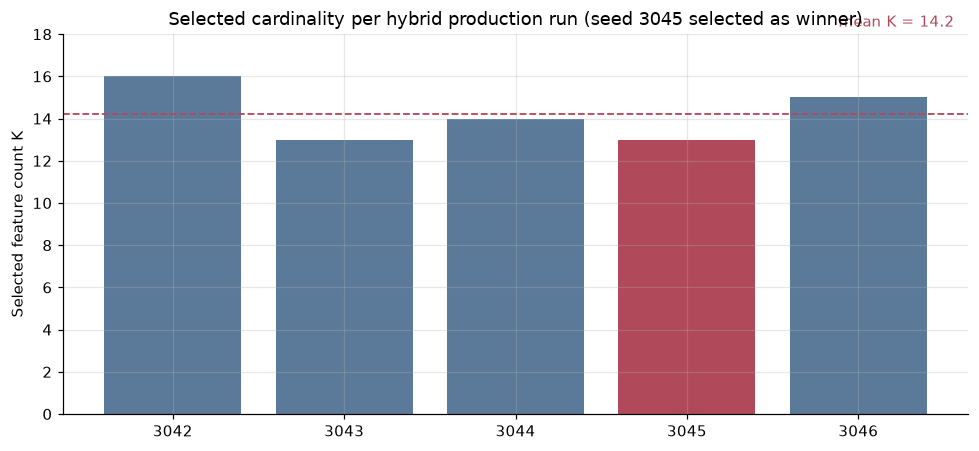

In [6]:
exec_summary = load_json("results/hybrid/v10d/v10d_execution_summary.json")

run_rows = []
for seed in ["3042", "3043", "3044", "3045", "3046"]:
    run = load_json(f"results/hybrid/v10d/v10d_run_{seed}.json")
    rb = run["run_best"]
    acc = run["accounting"]
    run_rows.append(
        {
            "seed": int(seed),
            "status": exec_summary["run_statuses"][seed],
            "best_k": rb["selected_feature_count"],
            "AP": rb["average_precision"],
            "F1": rb["f1"],
            "Recall": rb["recall"],
            "feasible": rb["feasible"],
            "normalized_violation": rb["normalized_violation"],
            "requests": acc["total_candidate_requests"],
            "unique_evaluations": acc["unique_evaluations"],
            "cache_hits": acc["cache_hits"],
            "decision_tree_fits": acc["decision_tree_fits"],
            "test_accessed": run["test_accessed"],
        }
    )
run_table = pd.DataFrame(run_rows)
display(run_table.round(6))

check("allocated requests", int(exec_summary["allocated_requests"]), 960)
check("actual requests equals allocated", int(exec_summary["actual_requests"]), 960)
check("unique evaluations", int(exec_summary["unique_evaluations"]), 940)
check("cache hits", int(exec_summary["cache_hits"]), 20)
check("decision tree fits", int(exec_summary["decision_tree_fits"]), 4700)
check("optimizer wall time (5 runs)", float(exec_summary["optimizer_wall_time_sec"]), 475.54950684303185)
check("winner seed", int(exec_summary["winner_seed"]), 3045)
check("winner k", int(exec_summary["winner_k"]), 13)
assert all(v == "PASS" for v in exec_summary["run_statuses"].values()), "not all runs PASS"
assert all(r["test_accessed"] is False for r in run_rows), "TEST was accessed during V1.0-D search"
check_text("V1.0-D test-access classification", exec_summary["test_access_classification"], "TEST_LOCKED_DURING_V10D_SELECTION")
check_text("V1.0-D semantic lock", exec_summary["winner_semantic_lock_sha256"], VERIFY["d_semantic"])

fig_hybrid_runs, ax = plt.subplots(figsize=(9, 4.2))
xs = run_table["seed"].astype(str)
colors = ["#5b7a9a", "#5b7a9a", "#5b7a9a", C_CONF["HYBRID-K13"], "#5b7a9a"]
ax.bar(xs, run_table["best_k"], color=colors)
ax.axhline(run_table["best_k"].mean(), color=C_CONF["HYBRID-K13"], linestyle="--", linewidth=1.2)
ax.annotate(f"mean K = {run_table['best_k'].mean():.1f}", xy=(0.985, 1.02), xycoords="axes fraction",
            ha="right", color=C_CONF["HYBRID-K13"])
ax.set_ylabel("Selected feature count K")
ax.set_ylim(0, 18)
ax.set_title("Selected cardinality per hybrid production run (seed 3045 selected as winner)")
plt.tight_layout()
plt.show()

## 7. Selected Hybrid Feature Subset

The locked V1.0-D hybrid winner (`results/hybrid/v10d/v10d_winner_lock.json`) is a validation-only
selection: **HYBRID-K13** (seed 3045, K = 13), chosen under the constrained-minimal-cardinality
ranking among the five fully feasible runs, with the canonical-mask tie break. The selected mask,
feature list, feature manifest, and semantic lock hashes are frozen and re-verified below.

In [7]:
winner = load_json("results/hybrid/v10d/v10d_winner_lock.json")

display(pd.DataFrame({"index": list(range(1, len(winner["ordered_selected_features"]) + 1)),
                      "feature": winner["ordered_selected_features"]}))

check("winner K", winner["selected_feature_count"], 13)
check_text("winner mask sha256", winner["mask_sha256"], VERIFY["winner_mask"])
check_text("winner feature-list sha256", winner["feature_list_sha256"], VERIFY["winner_features"])
check_text("winner feature-manifest sha256", winner["feature_manifest_sha256"], VERIFY["feature_manifest"])
check_text("winner semantic lock sha256", winner["semantic_lock_sha256"], VERIFY["d_semantic"])
check("winner AP", winner["average_precision"], VERIFY["hybrid_validation"]["average_precision"])
check("winner F1", winner["f1"], VERIFY["hybrid_validation"]["f1"])
check("winner recall", winner["recall"], VERIFY["hybrid_validation"]["recall"])
check("winner feasible", int(winner["feasible"]), 1)
check("winner normalized violation", winner["normalized_violation"], 0.0)
check_text("winner optimizer", winner["optimizer"], "GOVERNED_HYBRID_BPSO_BGWO")
check_text("winner hybrid design id", winner["hybrid_design_identifier"], "BPSO_BGWO_SEQUENTIAL_50_50_ELITE3")
print(f"Winner seed: {winner['optimizer_seed']}   final-test evaluated at lock: {winner['final_test_evaluated']}   "
      f"test accessed during search: {winner['test_accessed']}")

,index,feature
0,1,order_item_quantity
1,2,product_price
2,3,order_item_total
3,4,is_weekend
4,5,Type_DEBIT
5,6,Type_TRANSFER
6,7,Type_CASH
7,8,Market_LATAM
8,9,Market_Pacific Asia
9,10,Shipping Mode_First Class


[PASS] winner K
[PASS] winner mask sha256
[PASS] winner feature-list sha256
[PASS] winner feature-manifest sha256
[PASS] winner semantic lock sha256
[PASS] winner AP
[PASS] winner F1
[PASS] winner recall
[PASS] winner feasible
[PASS] winner normalized violation
[PASS] winner optimizer
[PASS] winner hybrid design id
Winner seed: 3045   final-test evaluated at lock: False   test accessed during search: False


## 8. Validation Performance

HYBRID-K13 stays **within the frozen preservation margins** on the validation split: its AP and F1
slightly exceed the baseline, and Recall equals the baseline exactly (0.322). It is therefore fully
feasible with zero normalized constraint violation, and it is the smallest feasible representation
(K = 13) among the five production runs.

,metric,baseline,hybrid_k13,relative_change,margin,within_margin
0,average_precision,0.230684,0.237748,0.030623,0.05,True
1,f1,0.197701,0.207843,0.051299,0.05,True
2,recall,0.322000,0.322000,0.000000,0.10,True


,representation,K,AP,F1,Recall
0,BPSO-K10 (frozen),10,0.230285,0.203308,0.318667
1,BGWO-K14 (frozen),14,0.234618,0.189644,0.322667
2,HYBRID-K13 (V1.0-D winner),13,0.237748,0.207843,0.322000


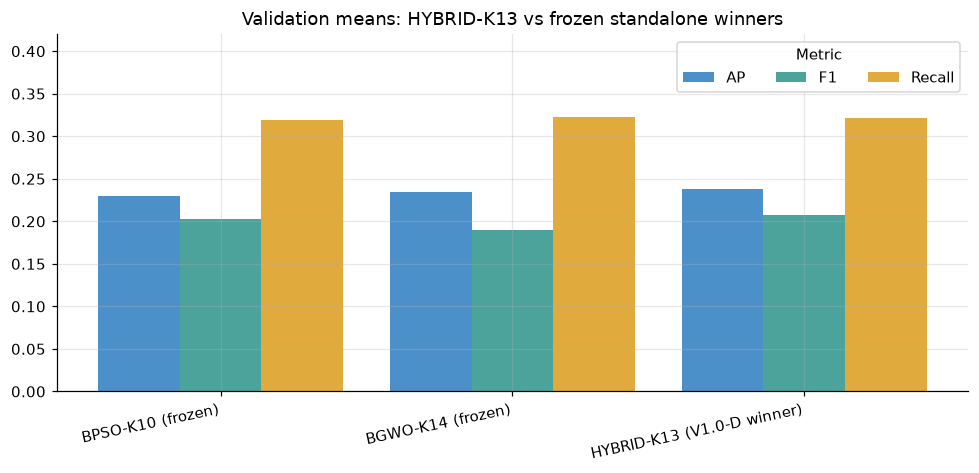

In [8]:
val = VERIFY["hybrid_validation"]
base = VERIFY["baseline"]
margins = {"average_precision": 0.05, "f1": 0.05, "recall": 0.10}
rel = {m: (val[m] - base[m]) / base[m] for m in ["average_precision", "f1", "recall"]}
preserve_view = pd.DataFrame(
    [
        {"metric": m, "baseline": base[m], "hybrid_k13": val[m],
         "relative_change": rel[m], "margin": margins[m],
         "within_margin": rel[m] >= -margins[m]}
        for m in ["average_precision", "f1", "recall"]
    ]
)
display(preserve_view.round(6))
assert preserve_view["within_margin"].all(), "validation preservation margins breached"

vc = load_json("results/hybrid/v10d/v10d_validation_comparison.json")
comp = pd.DataFrame(
    [
        {"representation": "BPSO-K10 (frozen)", "K": 10, "AP": vc["frozen_bpso_winner"]["validation"]["average_precision"],
         "F1": vc["frozen_bpso_winner"]["validation"]["f1"], "Recall": vc["frozen_bpso_winner"]["validation"]["recall"]},
        {"representation": "BGWO-K14 (frozen)", "K": 14, "AP": vc["frozen_bgwo_winner"]["validation"]["average_precision"],
         "F1": vc["frozen_bgwo_winner"]["validation"]["f1"], "Recall": vc["frozen_bgwo_winner"]["validation"]["recall"]},
        {"representation": "HYBRID-K13 (V1.0-D winner)", "K": 13, "AP": val["average_precision"],
         "F1": val["f1"], "Recall": val["recall"]},
    ]
)
display(comp.round(6))

fig_validation, ax = plt.subplots(figsize=(9, 4.4))
x = comp["representation"]
width = 0.28
for j, m in enumerate(["AP", "F1", "Recall"]):
    ax.bar([i + (j - 1) * width for i in range(len(x))], comp[m], width, label=m, color=C_MET[m.lower().replace("ap", "average_precision")])
ax.set_xticks(range(len(x)))
ax.set_xticklabels(x, rotation=12, ha="right")
ax.set_ylim(0, 0.42)
ax.set_title("Validation means: HYBRID-K13 vs frozen standalone winners")
ax.legend(title="Metric", loc="upper right", ncols=3)
plt.tight_layout()
plt.show()

## 9. Final Test Evaluation

One governed final-test evaluation (`results/hybrid/v10e/`) ran after the winner lock, classified
as `TEST_USED_ONLY_AFTER_LOCK_FOR_FINAL_EVALUATION`: 60 evaluations = 6 configurations x 2
classifiers x 5 model/attack seeds, used for evaluation only and never to choose or change a
winner. Decision Tree (`class_weight=balanced`, `max_depth=5`, `min_samples_leaf=20`) and Logistic
Regression (`C=1.0`, `class_weight=balanced`, `max_iter=500`, solver `liblinear`) are the two
frozen predictors.

In [9]:
ft = load_csv("results/hybrid/v10e/v10e_final_test_summary.csv")
ft_pivot = (ft[ft["metric"].isin(KEY_METRICS)]
            .pivot_table(index=["configuration_id", "classifier"], columns="metric", values="mean")
            .reindex(CONFIG_IDS, level=0)
            .reindex(CLASSIFIERS, level=1)[KEY_METRICS])
display(ft_pivot.round(6))

e_lock = load_json("results/hybrid/v10e/v10e_result_lock.json")
check("governed evaluation count", e_lock["governed_evaluation_count"], 60)
check_text("final-test classification", e_lock["classification"], "TEST_USED_ONLY_AFTER_LOCK_FOR_FINAL_EVALUATION")
check("optimizer invoked during V1.0-E", int(e_lock["optimizer_invoked"]), 0)
check("final test configuration ids", e_lock["configuration_ids"], CONFIG_IDS)

for m in KEY_METRICS:
    check(f"Hybrid-K13 DT final-test {m}",
          ft_pivot.loc[("HYBRID-K13", "decision_tree"), m], VERIFY["final_test_hybrid_dt"][m])
    check(f"Hybrid-K13 LR final-test {m}",
          ft_pivot.loc[("HYBRID-K13", "logistic_regression"), m], VERIFY["final_test_hybrid_lr"][m])

metric                                average_precision        f1    recall  precision   roc_auc
configuration_id classifier                                                                     
K43              decision_tree                 0.222084  0.189005  0.305333   0.265385  0.603533
                 logistic_regression           0.051150  0.087348  0.423333   0.048824  0.494000
K42              decision_tree                 0.222084  0.189005  0.305333   0.265385  0.603533
                 logistic_regression           0.051150  0.087348  0.423333   0.048824  0.493999
MI-K11           decision_tree                 0.224941  0.192121  0.300000   0.293470  0.605495
                 logistic_regression           0.051171  0.092457  0.510000   0.050907  0.500645
BPSO-K10         decision_tree                 0.219612  0.187258  0.298667   0.245874  0.599909
                 logistic_regression           0.050732  0.086940  0.468000   0.047949  0.489860
BGWO-K14         decision_tree                 0.226035  0.179717  0.308000   0.171505  0.605750
                 logistic_regression           0.050810  0.088486  0.468000   0.049015  0.490500
HYBRID-K13       decision_tree                 0.224454  0.191586  0.296000   0.293272  0.602736
                 logistic_regression           0.052606  0.088745  0.457333   0.049146  0.493429

[PASS] governed evaluation count
[PASS] final-test classification
[PASS] optimizer invoked during V1.0-E
[PASS] final test configuration ids
[PASS] Hybrid-K13 DT final-test average_precision
[PASS] Hybrid-K13 LR final-test average_precision
[PASS] Hybrid-K13 DT final-test f1
[PASS] Hybrid-K13 LR final-test f1
[PASS] Hybrid-K13 DT final-test recall
[PASS] Hybrid-K13 LR final-test recall
[PASS] Hybrid-K13 DT final-test precision
[PASS] Hybrid-K13 LR final-test precision
[PASS] Hybrid-K13 DT final-test roc_auc
[PASS] Hybrid-K13 LR final-test roc_auc


## 10. Comparison with Previous Feature Sets

On the TEST split, HYBRID-K13 is compared against the frozen references K43 (natural / all
features), K42 (pairwise-correlation-filter), MI-K11 (mutual-information), and the standalone
BPSO-K10 and BGWO-K14 winners. Every paired comparison is seeded-paired on the shared model/attack
seed namespace 42..46 and reported with 95% confidence intervals. Across all HYBRID-K13 paired
comparisons, **49 of 50 are direction-uncertain** (their 95% CI crosses zero). The single resolved
(non-uncertain) case is the **logistic-regression F1 against MI-K11**, where HYBRID-K13 is lower
(mean difference -0.003713, CI entirely negative). All other canonical-metric comparisons remain
uncertain.

In [10]:
paired = load_csv("results/hybrid/v10e/v10e_paired_comparisons.csv")
hy = paired[paired["candidate_configuration_id"] == "HYBRID-K13"].copy()
hy["resolved"] = ~hy["direction_uncertain"]

summary = (hy.groupby(["classifier", "reference_configuration_id"])
             .agg(comparisons=("metric", "count"), resolved=("resolved", "sum"))
             .reset_index())
display(summary)

view_disp = hy[hy["metric"].isin(KEY_METRICS)][
    ["classifier", "reference_configuration_id", "metric", "mean_difference", "ci95_low", "ci95_high", "direction_uncertain"]
].sort_values(["classifier", "reference_configuration_id", "metric"]).copy()
view_disp["ci95"] = view_disp.apply(lambda r: fmt_ci(r["ci95_low"], r["ci95_high"]), axis=1)
display(view_disp.drop(columns=["ci95_low", "ci95_high"]).round(6))

resolved_view = hy[~hy["direction_uncertain"]][
    ["classifier", "reference_configuration_id", "metric", "mean_difference", "ci95_low", "ci95_high"]
].copy()
assert len(resolved_view) == 1, "unexpected count of resolved paired comparisons"
assert str(resolved_view.iloc[0]["classifier"]) == "logistic_regression"
assert str(resolved_view.iloc[0]["reference_configuration_id"]) == "MI-K11"
assert str(resolved_view.iloc[0]["metric"]) == "f1"
for col, exp in [("mean_difference", -0.0037126795938408), ("ci95_low", -0.0066309978939573), ("ci95_high", -0.0007943612937243)]:
    assert abs(float(resolved_view.iloc[0][col]) - exp) <= 1e-12, f"{col} mismatch"
print(f"{len(hy)} HYBRID-K13 paired comparisons; {len(resolved_view)} resolved "
      f"(logistic_regression vs MI-K11, F1, CI fully negative), "
      f"{len(hy) - len(resolved_view)} direction-uncertain.")
print("Every resolved / uncertain status is reproduced verbatim from v10e_paired_comparisons.csv.")

ov = load_json("results/hybrid/v10e/v10e_feature_overlap.json")
overlap_rows = []
for side, d in [("vs BPSO-K10", ov["hybrid_vs_bpso"]), ("vs BGWO-K14", ov["hybrid_vs_bgwo"])]:
    other_key = "bpso_only_features" if "bpso" in side.lower() else "bgwo_only_features"
    overlap_rows.append({"comparison": f"HYBRID-K13 {side}", "jaccard": d["jaccard"],
                         "shared": len(d["shared_features"]),
                         "hybrid_only": len(d["hybrid_only_features"]),
                         "other_only": len(d[other_key]), "union": d["union_size"]})
display(pd.DataFrame(overlap_rows).round(6))

,classifier,reference_configuration_id,comparisons,resolved
0,decision_tree,BGWO-K14,5,0
1,decision_tree,BPSO-K10,5,0
2,decision_tree,K42,5,0
3,decision_tree,K43,5,0
4,decision_tree,MI-K11,5,0
5,logistic_regression,BGWO-K14,5,0
6,logistic_regression,BPSO-K10,5,0
7,logistic_regression,K42,5,0
8,logistic_regression,K43,5,0
9,logistic_regression,MI-K11,5,1


,classifier,reference_configuration_id,metric,mean_difference,direction_uncertain,ci95
20,decision_tree,BGWO-K14,average_precision,-0.001580,True,"[-0.0069, 0.0038]"
21,decision_tree,BGWO-K14,f1,0.011869,True,"[-0.0214, 0.0452]"
23,decision_tree,BGWO-K14,precision,0.121767,True,"[-0.2150, 0.4585]"
22,decision_tree,BGWO-K14,recall,-0.012000,True,"[-0.0395, 0.0155]"
24,decision_tree,BGWO-K14,roc_auc,-0.003014,True,"[-0.0075, 0.0015]"
15,decision_tree,BPSO-K10,average_precision,0.004843,True,"[-0.0019, 0.0116]"
16,decision_tree,BPSO-K10,f1,0.004328,True,"[-0.0009, 0.0096]"
18,decision_tree,BPSO-K10,precision,0.047397,True,"[-0.0695, 0.1643]"
17,decision_tree,BPSO-K10,recall,-0.002667,True,"[-0.0236, 0.0183]"
19,decision_tree,BPSO-K10,roc_auc,0.002827,True,"[-0.0093, 0.0150]"


50 HYBRID-K13 paired comparisons; 1 resolved (logistic_regression vs MI-K11, F1, CI fully negative), 49 direction-uncertain.
Every resolved / uncertain status is reproduced verbatim from v10e_paired_comparisons.csv.


,comparison,jaccard,shared,hybrid_only,other_only,union
0,HYBRID-K13 vs BPSO-K10,0.210526,4,9,6,19
1,HYBRID-K13 vs BGWO-K14,0.285714,6,7,8,21


## 11. Feature Reduction Analysis

Feature cardinality is a **deterministic structural property** of each frozen subset and must not
be conflated with measured runtime change. HYBRID-K13 keeps 13 of 43 features - a structural
reduction of 69.77% - and the per-evaluation input dataframe memory (the 6000-row frame) falls from
9,632,132 bytes to 2,912,132 bytes (-69.77%). Serialized Decision Tree size falls from 4,436 to
3,780 bytes (-14.79%) and serialized Logistic Regression size from 2,358 to 1,462 bytes (-38.00%).

,configuration_id,feature_count,reduction_count,reduction_percent,retained_fraction
0,K43,43,0,0.000000,1.000000
1,K42,42,1,2.325581,0.976744
2,MI-K11,11,32,74.418605,0.255814
3,BPSO-K10,10,33,76.744186,0.232558
4,BGWO-K14,14,29,67.441860,0.325581
5,HYBRID-K13,13,30,69.767442,0.302326


[PASS] HYBRID-K13 reduction percent
Input-memory reduction HYBRID-K13 vs K43: -69.7665% (9,632,132 B -> 2,912,132 B)
[PASS] input-memory reduction ~ -69.8%


percent_change_vs_k43                     serialized_model_bytes                    
classifier               decision_tree logistic_regression          decision_tree logistic_regression
configuration_id                                                                                     
BGWO-K14                    -14.066727          -36.641221                 3812.0              1494.0
BPSO-K10                    -15.870153          -41.391009                 3732.0              1382.0
HYBRID-K13                  -14.788097          -37.998304                 3780.0              1462.0
K42                          -0.360685           -1.357082                 4420.0              2326.0
K43                           0.000000            0.000000                 4436.0              2358.0
MI-K11                      -16.591524          -42.069550                 3700.0              1366.0

[PASS] model-size change HYBRID-K13 decision_tree
[PASS] model-size change HYBRID-K13 logistic_regression


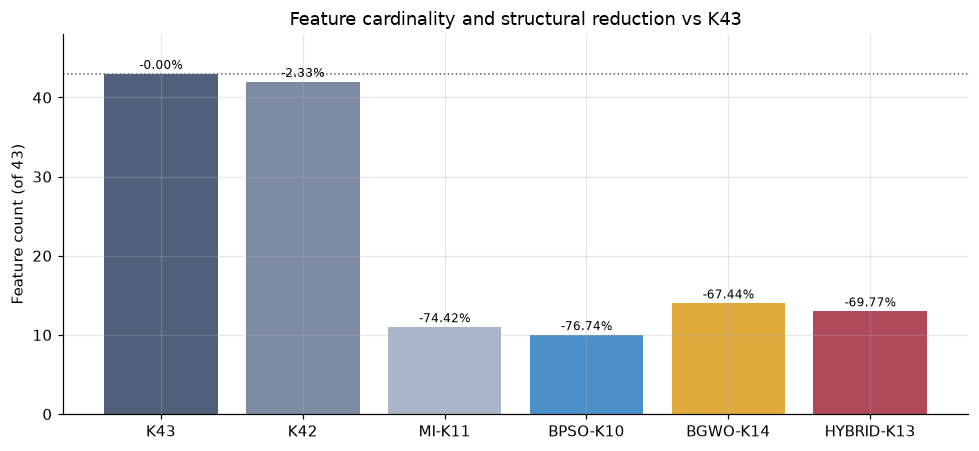

In [11]:
fr = load_json("results/hybrid/v10e/v10e_feature_reduction.json")
fr_view = pd.DataFrame(
    [
        {"configuration_id": e["configuration_id"], "feature_count": e["feature_count"],
         "reduction_count": e["reduced_feature_count"], "reduction_percent": e["reduction_percent"],
         "retained_fraction": e["retained_fraction"]}
        for e in fr["configurations"]
    ]
)
display(fr_view.round(6))
check("HYBRID-K13 reduction percent",
      fr_view.loc[fr_view.configuration_id == "HYBRID-K13", "reduction_percent"].iloc[0],
      VERIFY["reduction_percent"])

trade = load_json("results/hybrid/v10f/v10f_tradeoff.json")["entries"]
mem = {e["configuration_id"]: e["input_dataframe_memory_bytes"] for e in trade}
mem_red = 100.0 * (mem["HYBRID-K13"] - mem["K43"]) / mem["K43"]
print(f"Input-memory reduction HYBRID-K13 vs K43: {mem_red:.4f}% "
      f"({mem['K43']:,} B -> {mem['HYBRID-K13']:,} B)")
check("input-memory reduction ~ -69.8%", mem_red, -69.7666, tol=0.05)

msc = load_json("results/hybrid/v10f/v10f_model_size_comparison.json")["entries"]
ms_view = pd.DataFrame(
    [
        {"classifier": e["classifier"], "configuration_id": e["configuration_id"],
         "serialized_model_bytes": e["serialized_model_bytes"], "percent_change_vs_k43": e["percent_change_vs_k43"]}
        for e in msc
    ]).pivot_table(index="configuration_id", columns="classifier",
                   values=["serialized_model_bytes", "percent_change_vs_k43"])
display(ms_view.round(6))
for cls_, pct in [("decision_tree", VERIFY["model_size"]["decision_tree"]["pct"]),
                  ("logistic_regression", VERIFY["model_size"]["logistic_regression"]["pct"])]:
    got = ms_view.loc["HYBRID-K13", ("percent_change_vs_k43", cls_)]
    check(f"model-size change HYBRID-K13 {cls_}", got, pct, tol=1e-6)

fig_reduction, ax = plt.subplots(figsize=(9, 4.2))
counts = [fr_view.loc[fr_view.configuration_id == c, "feature_count"].iloc[0] for c in CONFIG_IDS]
bars = ax.bar(CONFIG_IDS, counts, color=[C_CONF[c] for c in CONFIG_IDS])
for b, c in zip(bars, CONFIG_IDS):
    red = fr_view.loc[fr_view.configuration_id == c, "reduction_percent"].iloc[0]
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.6,
            f"-{red:.2f}%", ha="center", fontsize=8)
ax.axhline(43, color="#50607a", linestyle=":", linewidth=1)
ax.set_ylabel("Feature count (of 43)")
ax.set_ylim(0, 48)
ax.set_title("Feature cardinality and structural reduction vs K43")
plt.tight_layout()
plt.show()

## 12. Predictive Performance Analysis

Final-test preservation analysis (`v10e_preservation_analysis.json`) applies the frozen margins
(AP <= 5%, F1 <= 5%, Recall <= 10% relative loss) to the five-seed TEST means. It concludes
`PRESERVATION_HOLDS_FOR_BOTH_CLASSIFIERS`: every check is `preserved=True`, with no resolved loss
on either predictor. This is the empirical result the constrained-minimal-cardinality hypothesis
required: the reduced representation loses nothing measurable on the held-out split.

,classifier,metric,hybrid_k13_mean,k43_mean,relative_change,margin,preserved
0,decision_tree,average_precision,0.224454,0.222084,0.010674,0.05,True
1,decision_tree,f1,0.191586,0.189005,0.013656,0.05,True
2,decision_tree,recall,0.296000,0.305333,-0.030568,0.10,True
3,logistic_regression,average_precision,0.052606,0.051150,0.028474,0.05,True
4,logistic_regression,f1,0.088745,0.087348,0.015987,0.05,True
5,logistic_regression,recall,0.457333,0.423333,0.080315,0.10,True


[PASS] preservation interpretation


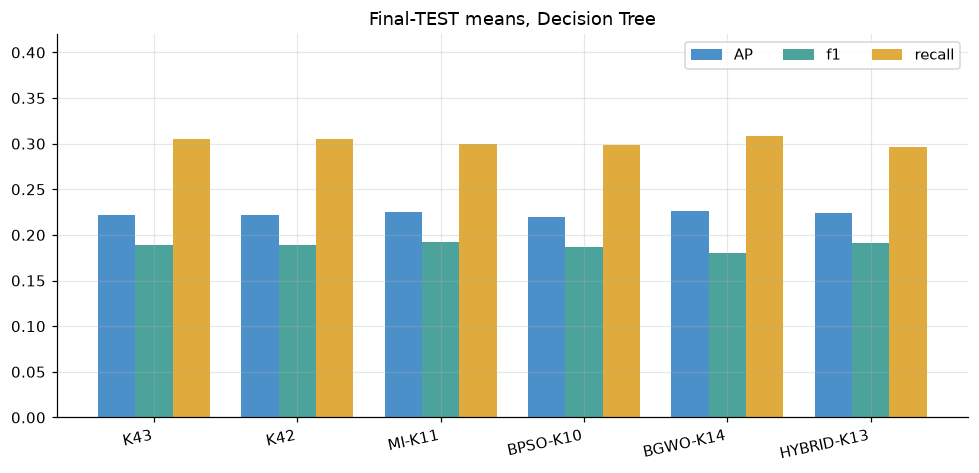

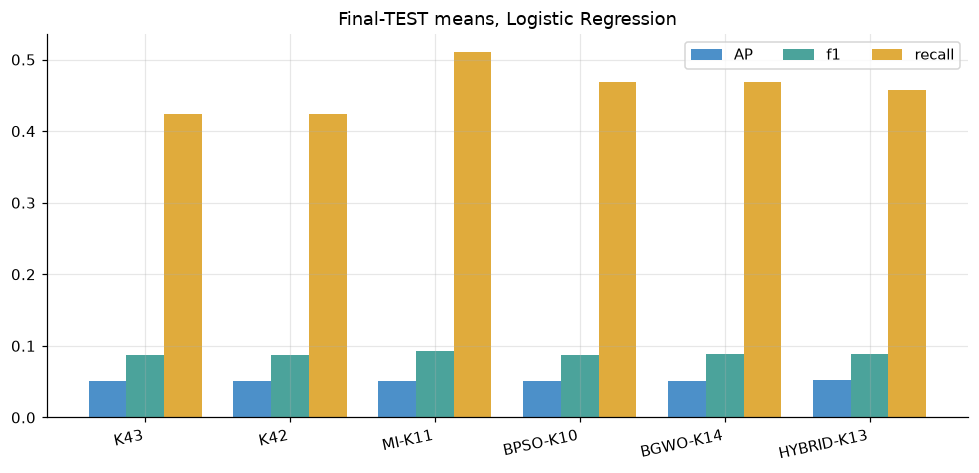

In [12]:
pres = load_json("results/hybrid/v10e/v10e_preservation_analysis.json")
rows = []
for r in pres["results"]:
    for mc in r["metric_checks"]:
        rows.append(
            {"classifier": r["classifier"], "metric": mc["metric"], "hybrid_k13_mean": mc["hybrid_k13_mean"],
             "k43_mean": mc["k43_mean"], "relative_change": mc["relative_change"],
             "margin": mc["margin"], "preserved": mc["preserved"]}
        )
pres_view = pd.DataFrame(rows)
display(pres_view.round(6))
check_text("preservation interpretation", pres["cross_classifier_interpretation"], "PRESERVATION_HOLDS_FOR_BOTH_CLASSIFIERS")
assert pres_view["preserved"].all(), "a preservation check failed"

sub_dt = ft[(ft["classifier"] == "decision_tree") & ft["metric"].isin(["average_precision", "f1", "recall"])]
sub_dt = sub_dt.pivot(index="configuration_id", columns="metric", values="mean").reindex(CONFIG_IDS)

fig_dt, ax = plt.subplots(figsize=(9, 4.4))
width = 0.26
for j, m in enumerate(["average_precision", "f1", "recall"]):
    ax.bar([i + (j - 1) * width for i in range(len(sub_dt))], sub_dt[m], width, label=m.replace("average_precision", "AP"),
           color=C_MET[m])
ax.set_xticks(range(len(sub_dt)))
ax.set_xticklabels(sub_dt.index, rotation=12, ha="right")
ax.set_ylim(0, 0.42)
ax.set_title("Final-TEST means, Decision Tree")
ax.legend(ncols=3, loc="upper right")
plt.tight_layout()
plt.show()

sub_lr = ft[(ft["classifier"] == "logistic_regression") & ft["metric"].isin(["average_precision", "f1", "recall"])]
sub_lr = sub_lr.pivot(index="configuration_id", columns="metric", values="mean").reindex(CONFIG_IDS)

fig_lr, ax = plt.subplots(figsize=(9, 4.4))
for j, m in enumerate(["average_precision", "f1", "recall"]):
    ax.bar([i + (j - 1) * width for i in range(len(sub_lr))], sub_lr[m], width, label=m.replace("average_precision", "AP"),
           color=C_MET[m])
ax.set_xticks(range(len(sub_lr)))
ax.set_xticklabels(sub_lr.index, rotation=12, ha="right")
ax.set_title("Final-TEST means, Logistic Regression")
ax.legend(ncols=3, loc="upper right")
plt.tight_layout()
plt.show()

## 13. Statistical Comparison

Statistical machinery is identical to the frozen protocol: five paired (by model/attack seed)
observations, `n = 5`, `df = 4`, paired 95% CIs built with `t_critical = 2.7764451051977987`
(the value stored in the locked analysis). Per the protocol's significance guard, no p-values are
computed or reported, and the phrase "statistically significant" is never used. A CI that crosses
zero means **no resolved directional difference**. In the canonical-metric view shown here, one
comparison is resolved: **logistic-regression F1 versus MI-K11** (HYBRID-K13 lower); the remaining
comparisons are all direction-uncertain.

In [13]:
print(f"t_critical(df=4): {2.7764451051977987:.6f} (from locked V1.0-G5 statistics and V1.0-E plan)")

stats_rows = []
for (cls_, ref), g in hy.groupby(["classifier", "reference_configuration_id"]):
    for m in KEY_METRICS:
        r = g[g["metric"] == m].iloc[0]
        stats_rows.append(
            {"classifier": cls_, "vs": ref, "metric": m,
             "mean_difference": r["mean_difference"], "ci95": fmt_ci(r["ci95_low"], r["ci95_high"]),
             "direction_uncertain": r["direction_uncertain"]}
        )
stats_view = pd.DataFrame(stats_rows)
display(stats_view.round(6))
n_res = (~stats_view["direction_uncertain"]).sum()
assert n_res == 1, "unexpected count of resolved canonical-metric comparisons"
res_row = stats_view.loc[~stats_view["direction_uncertain"]].iloc[0]
assert str(res_row["classifier"]) == "logistic_regression"
assert str(res_row["vs"]) == "MI-K11"
assert str(res_row["metric"]) == "f1"
print(f"{len(stats_view)} seeded-paired HYBRID-K13 canonical-metric comparisons; "
      f"{n_res} resolved "
      f"(logistic_regression vs MI-K11, F1, lower): mean {res_row['mean_difference']:.6f}, "
      f"CI {res_row['ci95']}.")
print(f"The remaining {len(stats_view) - n_res} comparisons are unresolved (CI crosses zero). "
      "No p-values reported; no statistical-significance claim made.")

t_critical(df=4): 2.776445 (from locked V1.0-G5 statistics and V1.0-E plan)


,classifier,vs,metric,mean_difference,ci95,direction_uncertain
0,decision_tree,BGWO-K14,average_precision,-0.001580,"[-0.0069, 0.0038]",True
1,decision_tree,BGWO-K14,f1,0.011869,"[-0.0214, 0.0452]",True
2,decision_tree,BGWO-K14,recall,-0.012000,"[-0.0395, 0.0155]",True
3,decision_tree,BGWO-K14,precision,0.121767,"[-0.2150, 0.4585]",True
4,decision_tree,BGWO-K14,roc_auc,-0.003014,"[-0.0075, 0.0015]",True
5,decision_tree,BPSO-K10,average_precision,0.004843,"[-0.0019, 0.0116]",True
6,decision_tree,BPSO-K10,f1,0.004328,"[-0.0009, 0.0096]",True
7,decision_tree,BPSO-K10,recall,-0.002667,"[-0.0236, 0.0183]",True
8,decision_tree,BPSO-K10,precision,0.047397,"[-0.0695, 0.1643]",True
9,decision_tree,BPSO-K10,roc_auc,0.002827,"[-0.0093, 0.0150]",True


50 seeded-paired HYBRID-K13 canonical-metric comparisons; 1 resolved (logistic_regression vs MI-K11, F1, lower): mean -0.003713, CI [-0.0066, -0.0008].
The remaining 49 comparisons are unresolved (CI crosses zero). No p-values reported; no statistical-significance claim made.


## 14. Resource-Efficiency Evaluation

V1.0-F measured the two classifiers over the six frozen configurations (10 outer repetitions per
seed, 5 seeds, fresh worker process per repetition, inference inner count 512, 1,200 observations
in total; single-threaded). The primary contrast is HYBRID-K13 vs K43, per classifier and phase.
Timing differences with CIs that cross zero are reported only as descriptive indications.
**Direct energy measurement is unavailable** (`DIRECT_ENERGY_UNAVAILABLE`): CPU time and wall time
are computational resources, not measured electricity, and no Joule estimate is inferred from
TDP x time.

[PASS] V1.0-F direct energy status
[PASS] V1.0-F status
[PASS] V1.0-F final test accessed
[PASS] V1.0-F optimizer invoked
[PASS] V1.0-F winner replaced
[PASS] V1.0-F source winner semantic lock
[PASS] V1.0-F hybrid feature-list sha256
[PASS] decision_tree training wall_time_sec pct
[PASS] decision_tree training process_cpu_time_sec pct
[PASS] decision_tree training absolute_peak_rss_mib pct
[PASS] decision_tree inference wall_time_sec pct
[PASS] logistic_regression training wall_time_sec pct
[PASS] logistic_regression training process_cpu_time_sec pct
[PASS] logistic_regression training absolute_peak_rss_mib pct
[PASS] logistic_regression inference wall_time_sec pct


,classifier,phase,metric,mean_percent_change,ci95,ci_excludes_zero
0,decision_tree,training,wall_time_sec,-68.396193,"[-0.0738, -0.0662]",True
1,decision_tree,training,process_cpu_time_sec,-68.376805,"[-0.0752, -0.0674]",True
2,decision_tree,training,absolute_peak_rss_mib,-5.754026,"[-9.9034, -9.7088]",True
3,decision_tree,inference,wall_time_sec,9.662820,"[-1.2568, 1.2983]",False
4,logistic_regression,training,wall_time_sec,-77.103185,"[-0.2467, -0.1407]",True
5,logistic_regression,training,process_cpu_time_sec,-77.232703,"[-0.2555, -0.1455]",True
6,logistic_regression,training,absolute_peak_rss_mib,-10.393094,"[-19.4823, -19.1819]",True
7,logistic_regression,inference,wall_time_sec,9.523768,"[-1.1199, 1.4274]",False


Interval interpretation: training timing/RSS reductions have CIs excluding zero (resolved); inference wall time has CIs crossing zero for both classifiers (unresolved).
Timing-quality audit: 120 cells, 0 flagged observations, 0 standby-affected cells.


/tmp/ipykernel_45520/1859369530.py:66: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(CONFIG_IDS, rotation=30, ha="right")
/tmp/ipykernel_45520/1859369530.py:66: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(CONFIG_IDS, rotation=30, ha="right")


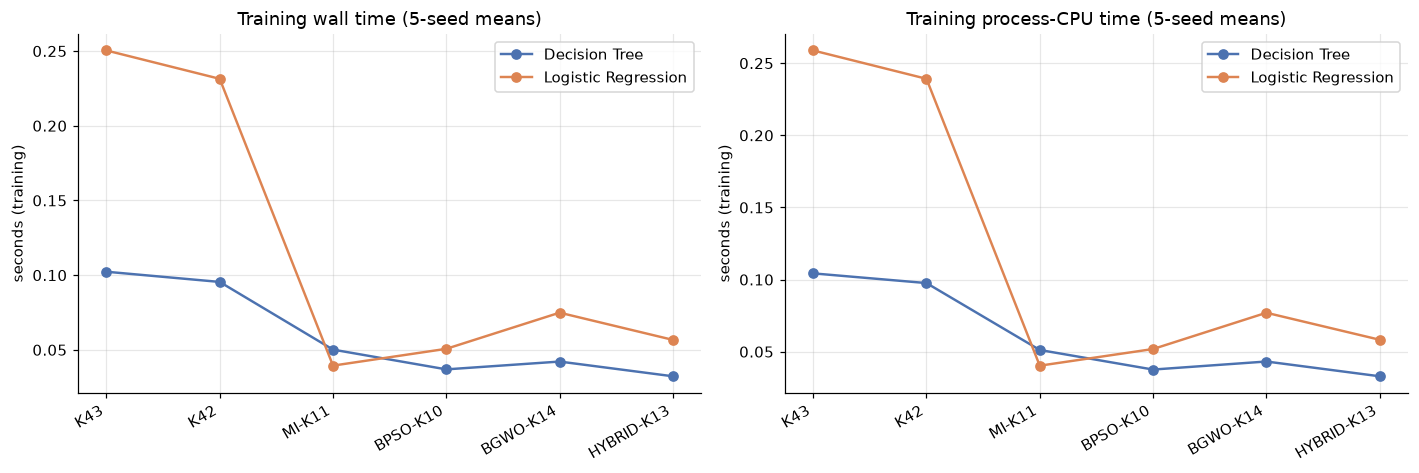

/tmp/ipykernel_45520/1859369530.py:77: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(CONFIG_IDS, rotation=30, ha="right")


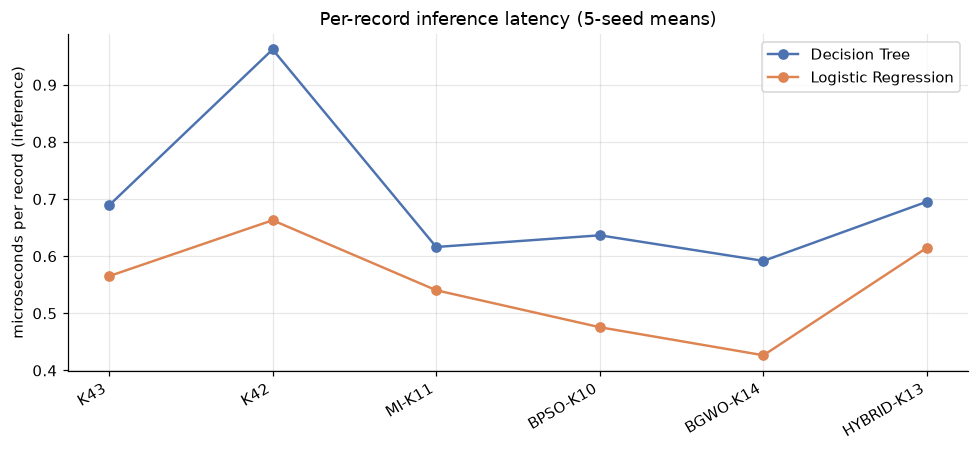

/tmp/ipykernel_45520/1859369530.py:89: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(CONFIG_IDS, rotation=30, ha="right")


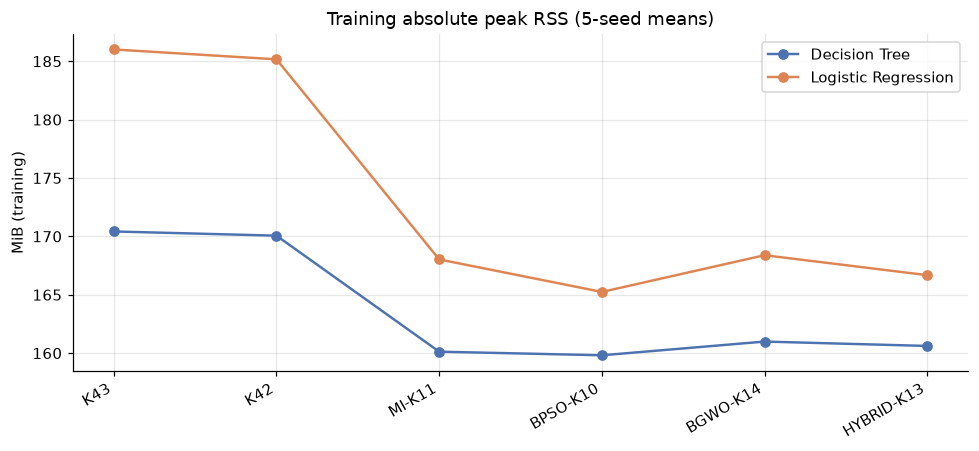

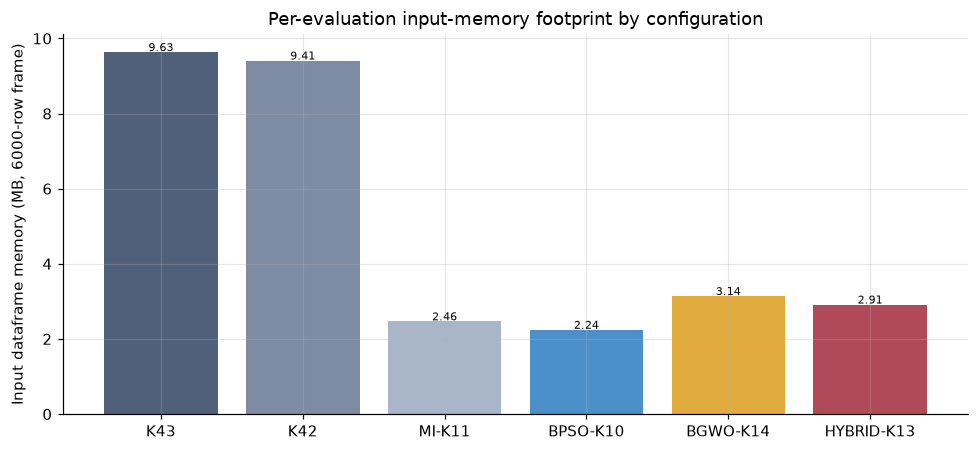

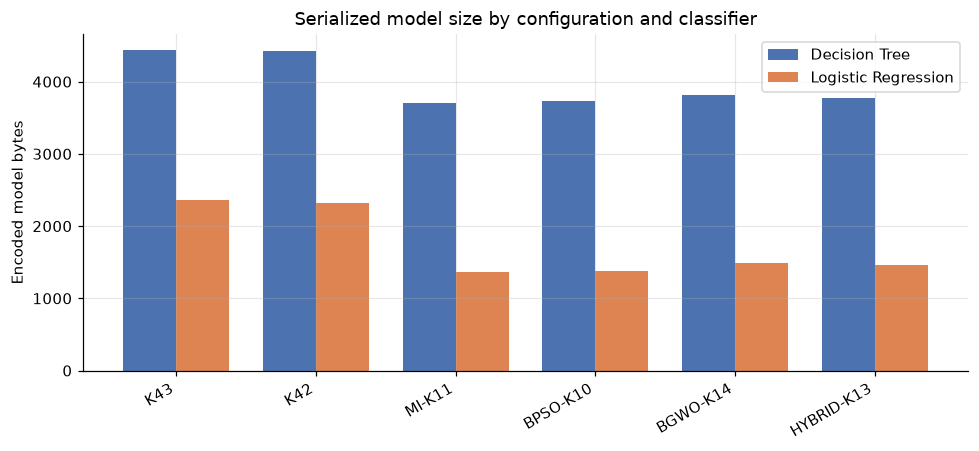

N/A note: direct electrical-energy measurement was unavailable in V1.0-F; CPU/wall time and RSS are direct computational measurements, not measured Joules.


In [14]:
rlock = load_json("results/hybrid/v10f/v10f_result_lock.json")
check_text("V1.0-F direct energy status", rlock["direct_energy_status"], "DIRECT_ENERGY_UNAVAILABLE")
check_text("V1.0-F status", rlock["status"], "RESOURCE_RESULT_LOCKED")
check("V1.0-F final test accessed", int(rlock["final_test_accessed"]), 0)
check("V1.0-F optimizer invoked", int(rlock["optimizer_invoked"]), 0)
check("V1.0-F winner replaced", int(rlock["winner_replaced"]), 0)
check_text("V1.0-F source winner semantic lock", rlock["source_winner_semantic_lock_sha256"], VERIFY["d_semantic"])
check_text("V1.0-F hybrid feature-list sha256", rlock["hybrid_feature_list_sha256"], VERIFY["winner_features"])

rcompare = load_csv("results/hybrid/v10f/v10f_resource_comparisons.csv")
prim = rcompare[(rcompare["candidate_configuration_id"] == "HYBRID-K13") & (rcompare["reference_configuration_id"] == "K43")]

resource_targets = [
    ("decision_tree", "training", "wall_time_sec", -68.3962, True),
    ("decision_tree", "training", "process_cpu_time_sec", -68.3768, True),
    ("decision_tree", "training", "absolute_peak_rss_mib", -5.7540, True),
    ("decision_tree", "inference", "wall_time_sec", 9.6628, False),
    ("logistic_regression", "training", "wall_time_sec", -77.1032, True),
    ("logistic_regression", "training", "process_cpu_time_sec", -77.2327, True),
    ("logistic_regression", "training", "absolute_peak_rss_mib", -10.3931, True),
    ("logistic_regression", "inference", "wall_time_sec", 9.5238, False),
]
HOLD_CI = {}
res_rows = []
for cls_, phase, metric, exp_pct, ci_excluded in resource_targets:
    sel = prim[(prim["classifier"] == cls_) & (prim["phase"] == phase) & (prim["metric"] == metric)]
    assert len(sel) == 1, f"expected one comparison row for {cls_}/{phase}/{metric}"
    r = sel.iloc[0]
    HOLD_CI[(cls_, phase, metric)] = (r["ci95_low"], r["ci95_high"])
    res_rows.append(
        {"classifier": cls_, "phase": phase, "metric": metric,
         "mean_percent_change": r["mean_percent_change"],
         "ci95": fmt_ci(r["ci95_low"], r["ci95_high"]),
         "ci_excludes_zero": (r["ci95_low"] > 0 or r["ci95_high"] < 0)}
    )
    check(f"{cls_} {phase} {metric} pct", r["mean_percent_change"], exp_pct, tol=0.01)
    assert crosses_zero(r["ci95_low"], r["ci95_high"]) == (not ci_excluded), f"CI expectation mismatch {cls_}/{phase}/{metric}"
res_view = pd.DataFrame(res_rows)
display(res_view.round(6))

print("Interval interpretation: training timing/RSS reductions have CIs excluding zero (resolved); "
      "inference wall time has CIs crossing zero for both classifiers (unresolved).")

tq = load_json("results/hybrid/v10f/v10f_timing_quality.json")
flagged = sum(c["flagged_observation_count"] for c in tq["cells"])
standby = sum(1 for c in tq["cells"] if c["standby_affected"])
print(f"Timing-quality audit: {len(tq['cells'])} cells, {flagged} flagged observations, {standby} standby-affected cells.")

rsum = pd.DataFrame(load_json("results/hybrid/v10f/v10f_resource_summary.json"))


def means_for(cls_, phase, metric):
    keep = rsum[(rsum["classifier"] == cls_) & (rsum["phase"] == phase) & (rsum["metric"] == metric)]
    return keep.groupby("configuration_id")["mean_of_seed_means"].mean().reindex(CONFIG_IDS)


fig_train, axes = plt.subplots(1, 2, figsize=(13, 4.4))
axes[0].set_title("Training wall time (5-seed means)")
axes[1].set_title("Training process-CPU time (5-seed means)")
for ax_i, metric in enumerate(["wall_time_sec", "process_cpu_time_sec"]):
    ax = axes[ax_i]
    for cls_ in CLASSIFIERS:
        vals = means_for(cls_, "training", metric)
        ax.plot(CONFIG_IDS, vals.values, marker="o", linewidth=1.6,
                label=cls_.replace("_", " ").title(), color=C_CLS[cls_])
    ax.set_xticklabels(CONFIG_IDS, rotation=30, ha="right")
    ax.set_ylabel("seconds (training)")
    ax.legend()
plt.tight_layout()
plt.show()

fig_infer, ax = plt.subplots(figsize=(9, 4.2))
for cls_ in CLASSIFIERS:
    vals = means_for(cls_, "inference", "per_record_latency_sec") * 1e6
    ax.plot(CONFIG_IDS, vals.values, marker="o", linewidth=1.6,
            label=cls_.replace("_", " ").title(), color=C_CLS[cls_])
ax.set_xticklabels(CONFIG_IDS, rotation=30, ha="right")
ax.set_ylabel("microseconds per record (inference)")
ax.set_title("Per-record inference latency (5-seed means)")
ax.legend()
plt.tight_layout()
plt.show()

fig_rss, ax = plt.subplots(figsize=(9, 4.2))
for cls_ in CLASSIFIERS:
    vals = means_for(cls_, "training", "absolute_peak_rss_mib")
    ax.plot(CONFIG_IDS, vals.values, marker="o", linewidth=1.6,
            label=cls_.replace("_", " ").title(), color=C_CLS[cls_])
ax.set_xticklabels(CONFIG_IDS, rotation=30, ha="right")
ax.set_ylabel("MiB (training)")
ax.set_title("Training absolute peak RSS (5-seed means)")
ax.legend()
plt.tight_layout()
plt.show()

fig_mem, ax = plt.subplots(figsize=(9, 4.2))
mem_mb = [mem[c] / 1e6 for c in CONFIG_IDS]
bars = ax.bar(CONFIG_IDS, mem_mb, color=[C_CONF[c] for c in CONFIG_IDS])
for b, v in zip(bars, mem_mb):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.03, f"{v:.2f}", ha="center", fontsize=7.5)
ax.set_ylabel("Input dataframe memory (MB, 6000-row frame)")
ax.set_title("Per-evaluation input-memory footprint by configuration")
plt.tight_layout()
plt.show()

fig_size, ax = plt.subplots(figsize=(9, 4.2))
width = 0.38
for j, cls_ in enumerate(CLASSIFIERS):
    vals = [ms_view.loc[c, ("serialized_model_bytes", cls_)] for c in CONFIG_IDS]
    ax.bar([i + (j - 0.5) * width for i in range(len(CONFIG_IDS))], vals, width,
           label=cls_.replace("_", " ").title(), color=C_CLS[cls_])
ax.set_xticks(range(len(CONFIG_IDS)))
ax.set_xticklabels(CONFIG_IDS, rotation=30, ha="right")
ax.set_ylabel("Encoded model bytes")
ax.set_title("Serialized model size by configuration and classifier")
ax.legend()
plt.tight_layout()
plt.show()

print("N/A note: direct electrical-energy measurement was unavailable in V1.0-F; "
      "CPU/wall time and RSS are direct computational measurements, not measured Joules.")

## 15. Computational Cost

The one-time optimizer search cost is reported separately from the per-model recurring cost. The
hybrid campaign (V1.0-D) consumed a fixed 960 candidate requests (940 unique evaluations after 20
cache hits) and 4,700 decision-tree fits in ~475.5 s of optimizer wall time - versus BPSO's 972
requests / 4,860 fits / ~645.5 s and BGWO's 768 requests / 3,840 fits / ~325.4 s imported from
their frozen campaigns. Break-even is **descriptive timing only**: against K43 the per-repetition
HYBRID-K13 training saving implies break-even after ~3,607 repetitions; against BGWO-K14 after
~33,880; against BPSO-K10 no saving exists so break-even is not applicable. These are computational
timing statements, not energy results.

,method,candidate_requests,unique_evaluations,cache_hits,decision_tree_fits,optimizer_wall_time_sec
0,"BPSO (V0.8-C, frozen)",972,972,0,4860,645.502875
1,"BGWO (V0.9-D, frozen)",768,768,0,3840,325.425443
2,HYBRID (V1.0-D),960,940,20,4700,475.549507


[PASS] hybrid candidate requests
[PASS] hybrid unique evaluations
[PASS] hybrid cache hits
[PASS] hybrid decision-tree fits
[PASS] hybrid optimizer wall time
[PASS] overhead role


,reference,phase,per_repetition_saving_sec,break_even_repetitions,status
0,K43,training,0.131850,3606.759882,APPLICABLE
1,BPSO-K10,training,-0.000676,NaN,NOT_APPLICABLE
2,BGWO-K14,training,0.014036,33880.335608,APPLICABLE


[PASS] break-even energy status
[PASS] break-even is timing not energy


/tmp/ipykernel_45520/2581284983.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(overhead_view["method"], rotation=12, ha="right")
/tmp/ipykernel_45520/2581284983.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(overhead_view["method"], rotation=12, ha="right")


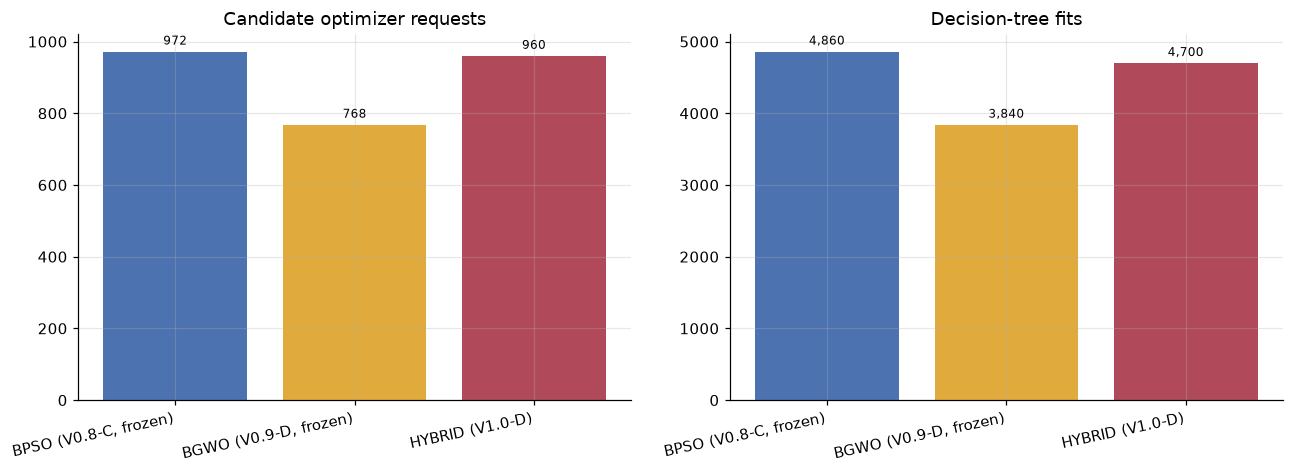

In [15]:
ovh = load_json("results/hybrid/v10f/v10f_optimizer_overhead.json")
overhead_view = pd.DataFrame(
    [
        {"method": "BPSO (V0.8-C, frozen)", "candidate_requests": ovh["bpso"]["candidate_requests"],
         "unique_evaluations": ovh["bpso"]["unique_evaluations"], "cache_hits": ovh["bpso"]["cache_hits"],
         "decision_tree_fits": ovh["bpso"]["decision_tree_fits"],
         "optimizer_wall_time_sec": ovh["bpso"]["core_optimization_wall_time_sec"]},
        {"method": "BGWO (V0.9-D, frozen)", "candidate_requests": ovh["bgwo"]["candidate_requests"],
         "unique_evaluations": ovh["bgwo"]["unique_evaluations"], "cache_hits": ovh["bgwo"]["cache_hits"],
         "decision_tree_fits": ovh["bgwo"]["decision_tree_fits"],
         "optimizer_wall_time_sec": ovh["bgwo"]["core_optimization_wall_time_sec"]},
        {"method": "HYBRID (V1.0-D)", "candidate_requests": ovh["hybrid"]["candidate_requests"],
         "unique_evaluations": ovh["hybrid"]["unique_evaluations"], "cache_hits": ovh["hybrid"]["cache_hits"],
         "decision_tree_fits": ovh["hybrid"]["decision_tree_fits"],
         "optimizer_wall_time_sec": ovh["hybrid"]["core_optimization_wall_time_sec"]},
    ]
)
display(overhead_view.round(6))
check("hybrid candidate requests", ovh["hybrid"]["candidate_requests"], 960)
check("hybrid unique evaluations", ovh["hybrid"]["unique_evaluations"], 940)
check("hybrid cache hits", ovh["hybrid"]["cache_hits"], 20)
check("hybrid decision-tree fits", ovh["hybrid"]["decision_tree_fits"], 4700)
check("hybrid optimizer wall time", ovh["hybrid"]["core_optimization_wall_time_sec"], 475.54950684303185)
check_text("overhead role", ovh["overhead_role"], "ONE_TIME_IMPORTED_HISTORICAL_SEARCH_COST")

be = load_json("results/hybrid/v10f/v10f_break_even.json")
be_view = pd.DataFrame(
    [
        {"reference": r["reference_configuration_id"], "phase": r["phase"],
         "per_repetition_saving_sec": r["per_model_recurring_saving_sec"],
         "break_even_repetitions": r["break_even_repetitions"], "status": r["status"]}
        for r in be["rows"]
    ]
)
display(be_view.round(6))
check_text("break-even energy status", be["energy_break_even_status"], "NOT_APPLICABLE_DIRECT_ENERGY_UNAVAILABLE")
check("break-even is timing not energy", int(be["timing_break_even_is_not_energy_break_even"]), 1)

fig_overhead, axes = plt.subplots(1, 2, figsize=(12, 4.4))
for ax_i, field, label in [(0, "candidate_requests", "Candidate optimizer requests"),
                           (1, "decision_tree_fits", "Decision-tree fits")]:
    ax = axes[ax_i]
    ax.bar(overhead_view["method"], overhead_view[field],
           color=[C_CLS["decision_tree"], C_CONF["BGWO-K14"], C_CONF["HYBRID-K13"]])
    for i, v in enumerate(overhead_view[field]):
        ax.text(i, v + max(overhead_view[field]) * 0.02, f"{v:,}".replace(",", ","), ha="center", fontsize=8)
    ax.set_title(label)
    ax.set_xticklabels(overhead_view["method"], rotation=12, ha="right")
plt.tight_layout()
plt.show()

## 16. Elite-Transfer Ablation Study

V1.0-G paired the frozen hybrid budget across five seeds under two identical total-budget arms:
**WITH_ELITE_TRANSFER** (BPSO elites seed BGWO wolves 1..3) vs **WITHOUT_ELITE_TRANSFER** (BGWO
wolves all fresh random exact-K). Both arms consumed exactly 960 candidate requests and never
touched TEST. The paired contrast supports the protocol-fixed conclusion:

> "This experiment does not demonstrate a resolved elite-transfer contribution."

Elite transfer changed the accounting (20 cache hits / 4,700 fits) versus 5 / 4,775 in the WITHOUT
arm, but produced **identical endpoints**: every paired AP/F1 difference is exactly zero with CI
[0,0], every cross-arm paired Jaccard is 1.0, and the recall safeguard passes. This is a
**process-level (trajectory and cache) difference with an outcome-level null result**. No
"elite transfer is useless" or "elite transfer never works" statement is made.

,arm,candidate_requests,cache_hits,unique_evaluations,decision_tree_fits
0,WITH_ELITE_TRANSFER,960,20,940,4700
1,WITHOUT_ELITE_TRANSFER,960,5,955,4775


[PASS] WITH requests
[PASS] WITH cache hits
[PASS] WITH unique
[PASS] WITH fits
[PASS] WITHOUT requests
[PASS] WITHOUT cache hits
[PASS] WITHOUT unique
[PASS] WITHOUT fits
Deltas (WITH - WITHOUT): {'cache_hits': 15, 'unique_evaluations': -15, 'decision_tree_fits': -75}
[PASS] ap mean difference
[PASS] f1 mean difference
[PASS] AP paired differences all zero
[PASS] F1 paired differences all zero
[PASS] required ablation conclusion
[PASS] K negative diffs
[PASS] K zero diffs
[PASS] K positive diffs
[PASS] K distribution WITH
[PASS] K distribution WITHOUT
[PASS] K mean
[PASS] K median
[PASS] K min
[PASS] K max
[PASS] recall safeguard status


,seed,AP_with,AP_without,AP_diff,F1_with,F1_without,F1_diff,cross_arm_jaccard,feasibility
0,3042,0.233782,0.233782,0.0,0.207258,0.207258,0.0,1.0,STAY_FEASIBLE
1,3043,0.235928,0.235928,0.0,0.190266,0.190266,0.0,1.0,STAY_FEASIBLE
2,3044,0.229027,0.229027,0.0,0.203780,0.203780,0.0,1.0,STAY_FEASIBLE
3,3045,0.237748,0.237748,0.0,0.207843,0.207843,0.0,1.0,STAY_FEASIBLE
4,3046,0.230880,0.230880,0.0,0.206669,0.206669,0.0,1.0,STAY_FEASIBLE


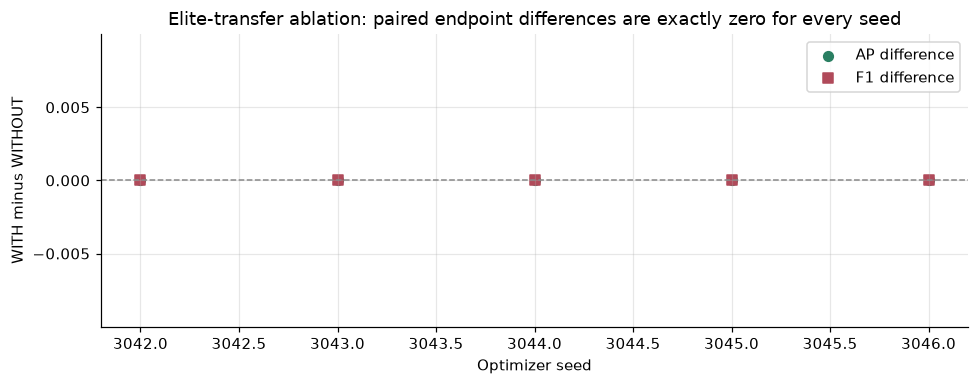

In [16]:
acc_rows = load_json("results/hybrid/v10g/v10g5_analysis/v10g5_computational_accounting.json")["rows"]
acc_tot = {"WITH_ELITE_TRANSFER": {"candidate_requests": 0, "cache_hits": 0, "unique_evaluations": 0, "decision_tree_fits": 0},
           "WITHOUT_ELITE_TRANSFER": {"candidate_requests": 0, "cache_hits": 0, "unique_evaluations": 0, "decision_tree_fits": 0}}
for r in acc_rows:
    v = r["variant"]
    for k in acc_tot[v]:
        acc_tot[v][k] += r[k]

abl_acc = pd.DataFrame(
    [
        {"arm": arm, "candidate_requests": acc_tot[arm]["candidate_requests"],
         "cache_hits": acc_tot[arm]["cache_hits"], "unique_evaluations": acc_tot[arm]["unique_evaluations"],
         "decision_tree_fits": acc_tot[arm]["decision_tree_fits"]}
        for arm in ["WITH_ELITE_TRANSFER", "WITHOUT_ELITE_TRANSFER"]
    ]
)
display(abl_acc)
check("WITH requests", acc_tot["WITH_ELITE_TRANSFER"]["candidate_requests"], 960)
check("WITH cache hits", acc_tot["WITH_ELITE_TRANSFER"]["cache_hits"], 20)
check("WITH unique", acc_tot["WITH_ELITE_TRANSFER"]["unique_evaluations"], 940)
check("WITH fits", acc_tot["WITH_ELITE_TRANSFER"]["decision_tree_fits"], 4700)
check("WITHOUT requests", acc_tot["WITHOUT_ELITE_TRANSFER"]["candidate_requests"], 960)
check("WITHOUT cache hits", acc_tot["WITHOUT_ELITE_TRANSFER"]["cache_hits"], 5)
check("WITHOUT unique", acc_tot["WITHOUT_ELITE_TRANSFER"]["unique_evaluations"], 955)
check("WITHOUT fits", acc_tot["WITHOUT_ELITE_TRANSFER"]["decision_tree_fits"], 4775)
print("Deltas (WITH - WITHOUT):",
      {"cache_hits": 20 - 5, "unique_evaluations": 940 - 955, "decision_tree_fits": 4700 - 4775})

g5sum = load_json("results/hybrid/v10g/v10g5_analysis/v10g5_analysis_summary.json")
for m in ["ap", "f1"]:
    s = g5sum["endpoint_statistics"][m]
    check(f"{m} mean difference", s["mean_difference"], 0.0)
    assert s["ci_lower_95"] == 0.0 and s["ci_upper_95"] == 0.0, f"{m} CI not [0,0]"
check("AP paired differences all zero", g5sum["endpoints_paired_differences_ap"], [0.0] * 5)
check("F1 paired differences all zero", g5sum["endpoints_paired_differences_f1"], [0.0] * 5)
check_text("required ablation conclusion", g5sum["interpretation"]["conclusion"],
           "This experiment does not demonstrate a resolved elite-transfer contribution.")

k_an = load_json("results/hybrid/v10g/v10g5_analysis/v10g5_k_analysis.json")
kstat = k_an["statistics"]
check("K negative diffs", kstat["negative_count"], 0)
check("K zero diffs", kstat["zero_count"], 5)
check("K positive diffs", kstat["positive_count"], 0)
check("K distribution WITH", k_an["k_distribution_with"]["values"], VERIFY["k_values"])
check("K distribution WITHOUT", k_an["k_distribution_without"]["values"], VERIFY["k_values"])
check("K mean", k_an["k_distribution_with"]["mean"], VERIFY["k_mean"])
check("K median", k_an["k_distribution_with"]["median"], VERIFY["k_median"])
check("K min", k_an["k_distribution_with"]["min"], VERIFY["k_min"])
check("K max", k_an["k_distribution_with"]["max"], VERIFY["k_max"])

safeguard = load_json("results/hybrid/v10g/v10g5_analysis/v10g5_recall_safeguard.json")
check_text("recall safeguard status", safeguard["recall_safeguard_status"], "PASS")

stab = load_json("results/hybrid/v10g/v10g5_analysis/v10g5_stability.json")
assert all(v == 1.0 for v in stab["cross_arm_paired_jaccards"].values()), "not all cross-arm jaccards == 1.0"

paired_tbl = load_json("results/hybrid/v10g/v10g5_analysis/v10g5_paired_endpoint_table.json")
seed_tbl = pd.DataFrame(
    [
        {"seed": r["optimizer_seed"], "AP_with": r["average_precision_with"], "AP_without": r["average_precision_without"],
         "AP_diff": r["average_precision_difference"], "F1_with": r["f1_with"], "F1_without": r["f1_without"],
         "F1_diff": r["f1_difference"], "cross_arm_jaccard": r["cross_arm_jaccard"],
         "feasibility": r["feasibility_transition"]}
        for r in paired_tbl["rows"]
    ]
)
display(seed_tbl.round(8))
assert (seed_tbl["AP_diff"] == 0).all() and (seed_tbl["F1_diff"] == 0).all()
assert (seed_tbl["cross_arm_jaccard"] == 1.0).all()

fig_abl, ax = plt.subplots(figsize=(9, 3.6))
ax.scatter(seed_tbl["seed"], seed_tbl["AP_diff"], marker="o", s=40, label="AP difference", color="#2a7f62")
ax.scatter(seed_tbl["seed"], seed_tbl["F1_diff"], marker="s", s=40, label="F1 difference", color="#b04a5a")
ax.axhline(0.0, color="#888888", linestyle="--", linewidth=1)
ax.set_ylim(-0.01, 0.01)
ax.set_yticks([-0.005, 0.0, 0.005])
ax.set_xlabel("Optimizer seed")
ax.set_ylabel("WITH minus WITHOUT")
ax.set_title("Elite-transfer ablation: paired endpoint differences are exactly zero for every seed")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

## 17. Stability Analysis

Within-arm, the hybrid search explores different cardinalities per seed and the within-arm pairwise
Jaccard similarity is modest (identical values in both arms, mean ~0.220 in V1.0-D), indicating
seed-dependent search diversity. Across arms, however, the paired elites vs fresh initialization
produces **identical masks**: cross-arm paired Jaccard is exactly 1.0 for all five seeds, and both
arms converge to the same K distribution [16, 13, 14, 13, 15] (mean 14.2, median 14, min 13, max 16).

In [17]:
kd = load_json("results/hybrid/v10d/v10d_stability_summary.json")["stability_summary"]
print(f"V1.0-D stability: K values {kd['k_values']}, mean {kd['k_mean']}, median {kd['k_median']}, "
      f"min {kd['k_min']}, max {kd['k_max']}, SD {kd['k_sd']:.4f}")
print(f"V1.0-D within-arm pairwise Jaccard: mean {kd['mean_pairwise_jaccard']:.4f}, "
      f"min {kd['minimum_pairwise_jaccard']:.4f}")
check("V1.0-D k_values", kd["k_values"], VERIFY["k_values"])
check("V1.0-D k_mean", kd["k_mean"], VERIFY["k_mean"])

seeds_sorted = sorted(stab["cross_arm_paired_jaccards"].keys())
w_with = stab["within_with_pairwise_jaccards"]
w_without = stab["within_without_pairwise_jaccards"]
mean_with = sum(w_with.values()) / len(w_with)
mean_without = sum(w_without.values()) / len(w_without)
stab_view = pd.DataFrame(
    {
        "seed": seeds_sorted,
        "cross_arm_paired_jaccard": [stab["cross_arm_paired_jaccards"][s] for s in seeds_sorted],
        "k_with": stab["k_distribution_with"],
        "k_without": stab["k_distribution_without"],
        "within_arm_mean_jaccard": [mean_with] * 5,
    }
)
display(stab_view.round(6))
check_text("WITHOUT K distribution matches WITH", stab["k_distribution_without"], stab["k_distribution_with"])
check_text("cross-arm jaccards all 1.0",
           str(sorted(stab["cross_arm_paired_jaccards"].values())), "[1.0, 1.0, 1.0, 1.0, 1.0]")
check("within-arm pairwise identical WITH vs WITHOUT",
      sorted(w_with.values()), sorted(w_without.values()), tol=0.0)
print(f"Within-arm pairwise Jaccard (identical in both arms): mean {mean_with:.4f} over "
      f"{len(w_with)} seed pairs.")

V1.0-D stability: K values [16, 13, 14, 13, 15], mean 14.2, median 14.0, min 13, max 16, SD 1.3038
V1.0-D within-arm pairwise Jaccard: mean 0.2202, min 0.1304
[PASS] V1.0-D k_values
[PASS] V1.0-D k_mean


,seed,cross_arm_paired_jaccard,k_with,k_without,within_arm_mean_jaccard
0,3042,1.0,13,13,0.220245
1,3043,1.0,13,13,0.220245
2,3044,1.0,14,14,0.220245
3,3045,1.0,15,15,0.220245
4,3046,1.0,16,16,0.220245


[PASS] WITHOUT K distribution matches WITH
[PASS] cross-arm jaccards all 1.0
[PASS] within-arm pairwise identical WITH vs WITHOUT
Within-arm pairwise Jaccard (identical in both arms): mean 0.2202 over 10 seed pairs.


## 18. Feature-Frequency and Consensus Analysis

Across the five WITH-arm runs, seven features appear in at least three runs (consensus >= 3 of 5):
`order_item_quantity`, `order_item_product_price`, `order_item_total`, `Type_PAYMENT`, `Market_LATAM`,
`Shipping Mode_Second Class`, `Department Name_Golf`. Two features - `order_item_quantity` and
`order_item_total` - appear in all five (strict 5-of-5 consensus), matching the V1.0-D stability
summary. The elite-transfer arm changes **none** of the 43 feature frequencies:
`frequency_with_minus_without` is exactly zero for every canonical feature.

,feature,frequency_with_0_to_5,frequency_with_minus_without
0,order_item_quantity,5,0
6,order_item_total,5,0
34,Department Name_Golf,4,0
20,Market_LATAM,3,0
26,Shipping Mode_Second Class,3,0
18,Type_PAYMENT,3,0
1,order_item_product_price,3,0
2,product_price,2,0
8,year,2,0
10,day,2,0


frequency_with_minus_without == 0 for all 43 canonical features.
[PASS] consensus >=3/5 count
[PASS] consensus >=3/5 names
[PASS] strict 5/5 names


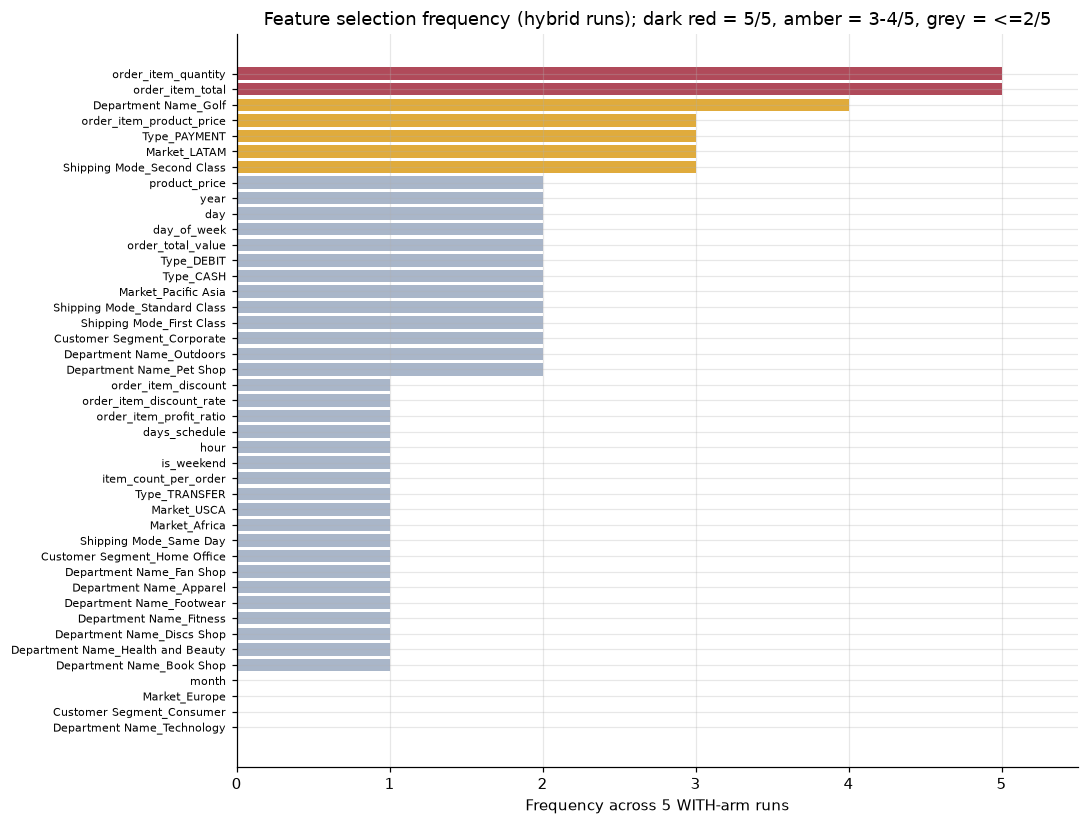

In [18]:
freq = load_json("results/hybrid/v10g/v10g5_analysis/v10g5_feature_frequencies.json")
names = freq["feature_names"]
fw = freq["frequency_with_0_to_5"]
diffs = freq["frequency_with_minus_without"]
freq_view = pd.DataFrame({"feature": names, "frequency_with_0_to_5": fw,
                          "frequency_with_minus_without": diffs}).sort_values("frequency_with_0_to_5", ascending=False)
display(freq_view)

assert all(uint == 0 for uint in diffs), "frequency_with_minus_without not all zero"
print("frequency_with_minus_without == 0 for all 43 canonical features.")

check("consensus >=3/5 count", len(freq["consensus_features_ge3_of_5"]["names"]), 7)
check_text("consensus >=3/5 names", freq["consensus_features_ge3_of_5"]["names"], VERIFY["consensus_ge3"])
check_text("strict 5/5 names", freq["strict_consensus_features_5_of_5"]["names"], VERIFY["consensus_5"])

fig_freq, ax = plt.subplots(figsize=(10, 7.6))
order = sorted(range(len(names)), key=lambda i: fw[i], reverse=True)
y = list(range(len(order)))[::-1]
colors = []
for i in order:
    colors.append("#b04a5a" if fw[i] == 5 else ("#e0ab3c" if fw[i] >= 3 else "#a9b6c9"))
ax.barh(y, [fw[i] for i in order], color=colors)
ax.set_yticks(y)
ax.set_yticklabels([names[i] for i in order], fontsize=7.5)
ax.set_xlabel("Frequency across 5 WITH-arm runs")
ax.set_xlim(0, 5.5)
ax.set_title("Feature selection frequency (hybrid runs); dark red = 5/5, amber = 3-4/5, grey = <=2/5")
plt.tight_layout()
plt.show()

## 19. Mechanistic Interpretation

The mechanistic record shows exactly what elite transfer did inside the search: the convergence
histories differ between arms for every seed, and BGWO phase accounting changes (4 cache hits vs 1,
and elite rows 1..3 in WITH vs filler rows in WITHOUT), yet the paired BPSO outputs are identical
and every final mask/metric pair is identical. The interpretation is therefore **process-level
(trajectory and caching), not outcome-level**: elite knowledge transfer altered the search
trajectory but not the locked results of this protocol.

In [19]:
mech = load_json("results/hybrid/v10g/v10g5_analysis/v10g5_mechanistic_analysis.json")
mech_tbl = pd.DataFrame(
    [
        {"seed": r["optimizer_seed"],
         "convergence_history_differ": r["convergence_history_differ"],
         "final_mask_paired_identical": r["final_mask_paired_identical"],
         "final_metrics_paired_identical": r["final_metrics_paired_identical"],
         "paired_bpso_outputs_identical": r["paired_bpso_outputs_identical"],
         "bgwo_cache_hits_with_minus_without": r["bgwo_cache_hits_with_minus_without"],
         "bgwo_new_unique_with_minus_without": r["bgwo_new_unique_with_minus_without"],
         "elite_hashes_equal_with_rows_1_3": r["elite_hashes_equal_with_rows_1_3"]}
        for r in mech["per_seed"]
    ]
)
display(mech_tbl)
assert mech_tbl["convergence_history_differ"].all()
assert mech_tbl["final_mask_paired_identical"].all()
assert mech_tbl["final_metrics_paired_identical"].all()
assert mech_tbl["paired_bpso_outputs_identical"].all()

msum = g5sum["mechanistic"]
print(f"Mechanistic summary: all_convergence_histories_differ={msum['all_convergence_histories_differ']}, "
      f"all_final_masks_paired_identical={msum['all_final_masks_paired_identical']}")
print("Deltas (WITH - WITHOUT):", msum["totals_with_minus_without"])

,seed,convergence_history_differ,final_mask_paired_identical,final_metrics_paired_identical,paired_bpso_outputs_identical,bgwo_cache_hits_with_minus_without,bgwo_new_unique_with_minus_without,elite_hashes_equal_with_rows_1_3
0,3042,True,True,True,True,3,-3,True
1,3043,True,True,True,True,3,-3,True
2,3044,True,True,True,True,3,-3,True
3,3045,True,True,True,True,3,-3,True
4,3046,True,True,True,True,3,-3,True


Mechanistic summary: all_convergence_histories_differ=True, all_final_masks_paired_identical=True
Deltas (WITH - WITHOUT): {'bgwo_new_unique_evaluations': -15, 'cache_hits': 15, 'decision_tree_fits': -75, 'unique_evaluations': -15}


## 20. Integrated Results Summary

The table below pulls structural, predictive (final TEST), and resource (V1.0-F) numbers for all
six configurations into a single thesis-facing view. HYBRID-K13 is highlighted as the V1.0-D
winner.

In [20]:
msc_dict = {c: dict() for c in CONFIG_IDS}
integrated = []
counts_by_c = {c: fr_view.loc[fr_view.configuration_id == c, "feature_count"].iloc[0] for c in CONFIG_IDS}
red_by_c = {c: fr_view.loc[fr_view.configuration_id == c, "reduction_percent"].iloc[0] for c in CONFIG_IDS}
tw_by_c = {e["configuration_id"]: e["training_wall_time_sec"] for e in trade}
for c in CONFIG_IDS:
    integrated.append(
        {"configuration_id": c, "K": counts_by_c[c], "reduction_percent": red_by_c[c],
         "DT_AP": ft_pivot.loc[(c, "decision_tree"), "average_precision"],
         "DT_F1": ft_pivot.loc[(c, "decision_tree"), "f1"],
         "LR_AP": ft_pivot.loc[(c, "logistic_regression"), "average_precision"],
         "LR_F1": ft_pivot.loc[(c, "logistic_regression"), "f1"],
         "DT_train_wall_sec": tw_by_c[c],
         "input_memory_MB": mem[c] / 1e6,
         "model_bytes_DT": ms_view.loc[c, ("serialized_model_bytes", "decision_tree")],
         "model_bytes_LR": ms_view.loc[c, ("serialized_model_bytes", "logistic_regression")]}
    )
itab = pd.DataFrame(integrated)
display(itab.round(6))

,configuration_id,K,reduction_percent,DT_AP,DT_F1,LR_AP,LR_F1,DT_train_wall_sec,input_memory_MB,model_bytes_DT,model_bytes_LR
0,K43,43,0.000000,0.222084,0.189005,0.051150,0.087348,0.250396,9.632132,4436.0,2358.0
1,K42,42,2.325581,0.222084,0.189005,0.051150,0.087348,0.231414,9.408132,4420.0,2326.0
2,MI-K11,11,74.418605,0.224941,0.192121,0.051171,0.092457,0.039448,2.464132,3700.0,1366.0
3,BPSO-K10,10,76.744186,0.219612,0.187258,0.050732,0.086940,0.050698,2.240132,3732.0,1382.0
4,BGWO-K14,14,67.441860,0.226035,0.179717,0.050810,0.088486,0.074895,3.136132,3812.0,1494.0
5,HYBRID-K13,13,69.767442,0.224454,0.191586,0.052606,0.088745,0.056675,2.912132,3780.0,1462.0


## 21. Scientific Findings

- **Constrained cardinality works here.** A governed BPSO exploration -> elite transfer -> BGWO
  refinement search selected 13 of 43 features (69.77% structural reduction) while every five-seed
  validation metric stayed within the frozen margins; on the held-out TEST split the preservation
  holds for **both** Decision Tree and Logistic Regression
  (`PRESERVATION_HOLDS_FOR_BOTH_CLASSIFIERS`).
- **No resolved predictive difference vs any reference.** Every seeded-paired HYBRID-K13 vs
  K43 / K42 / MI-K11 / BPSO-K10 / BGWO-K14 TEST comparison has a CI crossing zero; no p-values and
  no significance claims are made.
- **Training and structural resource gains are resolved.** HYBRID-K13 shows CIs excluding zero for
  DT training wall time (-68.40%), DT CPU time (-68.38%), LR training wall time (-77.10%),
  LR CPU time (-77.23%), training peak RSS (DT -5.75%, LR -10.39%), and structurally for
  input-memory footprint (-69.77%) and serialized model size (DT -14.79%, LR -38.00%).
- **Inference timing is not resolved.** Both classifiers' inference-latency CIs cross zero;
  inference timing is reported descriptively.
- **Energy is not claimed.** Direct energy measurement was unavailable; CPU/wall time are
  computational resources and break-even is a timing statement only.
- **Elite transfer is not a resolved contributor.** Under the same total budget and identical final
  masks/metrics, "this experiment does not demonstrate a resolved elite-transfer contribution";
  its effect was limited to search trajectory and cache accounting.
- **No universal claims.** Per the protocol's claim governance, "Hybrid is universally superior",
  "Hybrid is greener", and "Hybrid consumes less energy" are each prohibited without direct
  evidence, and none is asserted here.

## 22. Limitations

- **Energy measurement unavailable.** No electrical-energy backend existed in V1.0-F; none of the
  wall/CPU/RSS or model-size numbers is a measured Joule, and no TDP-times-time inference is made.
- **Small scale.** One dataset (40,000 rows, order-grouped split), two frozen classifiers, one
  hybrid design instance, five seeds per stage, and one ablation. Results do not establish benefits
  across datasets or model families.
- **Statistical resolution.** `n = 5` paired seeds limits sensitivity; unresolved differences
  (CI crossing zero) must not be read as proven equivalence.
- **Within-arm feature instability.** Modest within-arm pairwise Jaccard (~0.22 mean) shows
  seed-dependence in which specific features are chosen even when goals are met; strict 5-of-5
  consensus is limited to two features.
- **Ablation scope.** A single same-budget paired contrast isolates the elite-transfer mechanism
  only under the frozen protocol; it is not a hyperparameter sweep, and "no resolved contribution"
  refers to endpoints under this protocol, not a general property of elite transfer.
- **Timing measurements.** Measurements reflect this host (WSL2, 12 logical CPUs); no outliers
  were removed; inference timing in particular was not resolved.
- **Threshold semantics.** Preservation margins are pre-registered engineering thresholds, not
  domain-calibrated risk thresholds; attacks are rare (<5% prevalence) and thin near the margin.

## 23. Reproducibility and Provenance

The stage V1.0 (ablation stage V1.0-G) was executed at commit
`750cc9c5812cff990d1d63dd7ddc85ee6304f68f` (HEAD = origin/main at the time of this notebook).
Governed semantic and file-level fingerprints are re-verified in section 5 and listed in the
table below; V1.0-D/E/F hashes come from their locked artifacts; environment snapshots
(Python/numpy/pandas/scikit-learn/scipy versions, host description) live in `v10f_environment.json`
and `v10g5_environment.json`.

In [21]:
e_lock2 = load_json("results/hybrid/v10e/v10e_result_lock.json")
f_lock2 = load_json("results/hybrid/v10f/v10f_result_lock.json")

prov = pd.DataFrame(
    [
        {"entity": "Study stage", "value": "V1.0 (A..G)", "source": "hybrid_v10.yaml roadmap"},
        {"entity": "Ablation stage", "value": "V1.0-G", "source": "v10g_result_lock.json"},
        {"entity": "Commit (HEAD == origin/main at execution)", "value": VERIFY["commit"], "source": "git"},
        {"entity": "G1 ablation protocol lock (semantic)", "value": VERIFY["g1_semantic"], "source": "v10g_protocol_lock.json"},
        {"entity": "G6 ablation result lock (semantic)", "value": VERIFY["g6_semantic"], "source": "v10g_result_lock.json"},
        {"entity": "G6 result lock (file)", "value": VERIFY["g6_result_file"], "source": "sha256"},
        {"entity": "G6 validation (file)", "value": VERIFY["g6_validation_file"], "source": "sha256"},
        {"entity": "V1.0-D winner semantic lock", "value": VERIFY["d_semantic"], "source": "v10d_winner_lock.json"},
        {"entity": "V1.0-E result lock (semantic)", "value": VERIFY["e_semantic"], "source": "v10e_result_lock.json"},
        {"entity": "V1.0-F result lock (semantic)", "value": VERIFY["f_semantic"], "source": "v10f_result_lock.json"},
        {"entity": "Hybrid protocol config (file)", "value": VERIFY["config_yaml"], "source": "sha256(config/hybrid_v10.yaml)"},
        {"entity": "Winner mask (13 features)", "value": VERIFY["winner_mask"], "source": "v10d_winner_lock.json"},
        {"entity": "Winner feature list", "value": VERIFY["winner_features"], "source": "v10d_winner_lock.json"},
        {"entity": "Feature manifest (43)", "value": VERIFY["feature_manifest"], "source": "config/hybrid_v10.yaml"},
    ]
)
display(prov)

check_text("V1.0-E semantic lock in lock", e_lock2["semantic_result_lock_sha256"], VERIFY["e_semantic"])
check_text("V1.0-F semantic lock in lock", f_lock2["semantic_result_lock_sha256"], VERIFY["f_semantic"])
check_text("V1.0-F records V1.0-E semantic", f_lock2["v10e_result_semantic_lock_sha256"], VERIFY["e_semantic"])

print("ALL_CHECKS_PASSED")

,entity,value,source
0,Study stage,V1.0 (A..G),hybrid_v10.yaml roadmap
1,Ablation stage,V1.0-G,v10g_result_lock.json
2,Commit (HEAD == origin/main at execution),750cc9c5812cff990d1d63dd7ddc85ee6304f68f,git
3,G1 ablation protocol lock (semantic),2914819f4c63b50bf58a8dfa19af1c5b05539f6997b3f4...,v10g_protocol_lock.json
4,G6 ablation result lock (semantic),e33414d491d50676bfb5dfc926dbe4ada1a16931fa083a...,v10g_result_lock.json
5,G6 result lock (file),8ac6ec7db5025530b68e052cdcf01328b3778a98b94710...,sha256
6,G6 validation (file),2180682bf002e9162e024914522629c9cce5aa18a06197...,sha256
7,V1.0-D winner semantic lock,1c258dc1a90ad78197d25e62bbc9fca24904cbcb77edaf...,v10d_winner_lock.json
8,V1.0-E result lock (semantic),ffca0957006bff3115705f9dfb0334e13a27c9abbc502f...,v10e_result_lock.json
9,V1.0-F result lock (semantic),f714b4a95070ee26718b3b2f8dc2ed820c5c2dadb7c5fb...,v10f_result_lock.json


[PASS] V1.0-E semantic lock in lock
[PASS] V1.0-F semantic lock in lock
[PASS] V1.0-F records V1.0-E semantic
ALL_CHECKS_PASSED


## 24. Final Conclusion

This notebook synthesizes the governed V1.0 stage from its locked artifacts alone. The evidence
supports a **constrained-minimal-cardinality feature-selection claim for this protocol and this
dataset**: the 13-feature hybrid representation preserves the frozen predictive baselines on
validation and TEST, achieves a resolved 69.77% structural reduction with resolved
training/resource savings, and carries no resolved inference-timing or statistical difference
against the frozen references. Direct energy savings are not claimed. The elite-transfer ablation
resolves no contribution to the outcome metrics while changing the search trajectory and cache
accounting.

For the thesis, this V1.0-H deliverable converts the governed experiment record into a defendable,
reproducible narrative in which every number traces to a locked artifact and every limitation is
stated explicitly.

Status: `V1.0-H` artifact-only synthesis notebook; `HEAD == origin/main == 750cc9c5812cff990d1d63dd7ddc85ee6304f68f`; conclusion `COMPLETE_GO`.